In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/Attentive_FP/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Attentive_FP


#패키지 설치

In [ ]:
# --- 패키지 설치 ---
!pip install rdkit numpy==1.26.4
!pip install torch==2.3.0 torchvision==0.18.0 torchaudio==2.3.0
!pip install torch_scatter torch_sparse -f https://data.pyg.org/whl/torch-2.3.0+cu121.html
!pip install torch_geometric
!pip install shap==0.45.1 optuna


  Using cached torch-2.3.0-cp312-cp312-manylinux1_x86_64.whl.metadata (26 kB)
  Using cached torchvision-0.18.0-cp312-cp312-manylinux1_x86_64.whl.metadata (6.6 kB)
  Using cached torchaudio-2.3.0-cp312-cp312-manylinux1_x86_64.whl.metadata (6.4 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl.metadata (1.6 k

#1.라이브러리 임포트

In [ ]:
# --- 라이브러리 임포트 ---
import pandas as pd
import numpy as np
import copy
from tqdm.auto import tqdm
from collections import defaultdict
import traceback

# RDKit
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.DataStructs import TanimotoSimilarity
from rdkit.Chem import MACCSkeys
from rdkit.Chem import Descriptors

# PyTorch & PyTorch Geometric
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_add_pool, GATv2Conv, BatchNorm
from torch_geometric.utils import softmax as pyg_softmax
from torch_scatter import scatter_add

# Scikit-learn & SciPy
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, f1_score, matthews_corrcoef
from scipy.stats import fisher_exact
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import StandardScaler

# 시각화
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import shap

# RDKit, SciPy, Pandas, TQDM 임포트
from rdkit import Chem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
import pandas as pd
from collections import defaultdict
from scipy.stats import fisher_exact
from tqdm.auto import tqdm

from rdkit.Chem import MolFromSmiles
from rdkit.Chem import Draw
import numpy as np
import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem

#이미지 처리를 위한 라이브러리
from IPython.display import display, HTML
import base64
from io import BytesIO

import matplotlib.colors as mcolors # ◀️ 라이브러리 추가 임포트
from rdkit.Chem.Draw import MolDraw2DCairo
from PIL import Image
import io

import os
from contextlib import redirect_stdout
from datetime import datetime

#2. 헬퍼 함수

In [ ]:
def format_metric(value):
    """
    입력값이 숫자, 텐서, numpy 배열이든 상관없이
    안전하게 소수점 4자리 문자열로 변환하는 함수.
    """
    # 값이 하나뿐인 텐서나 배열일 경우, 숫자(float)만 추출
    if isinstance(value, torch.Tensor) and value.numel() == 1:
        value = value.item()
    elif isinstance(value, np.ndarray) and value.size == 1:
        value = value.item()
    elif isinstance(value, np.ndarray): # 여러 값을 가진 numpy 배열의 경우, 문자열로 변환
        return np.array2string(value, precision=4, separator=', ')

    # 이제 value는 순수한 숫자이므로 안전하게 포맷팅
    if isinstance(value, (int, float)):
        return f"{value:.4f}"
    else:
        # 그 외의 경우는 그냥 문자열로 반환
        return str(value)

###2.1 AttentiveFP 모델 정의

In [ ]:
# RDKit에서 계산 가능한 200여개 디스크립터 목록

def one_of_k_encoding(x, allowable_set):
    """주어진 집합(allowable_set)에 대해 원-핫 인코딩 벡터를 생성합니다."""
    if x not in allowable_set:
        raise Exception(f"입력 {x}가 허용된 집합 {allowable_set}에 없습니다.")
    return [x == s for s in allowable_set]

def one_of_k_encoding_unk(x, allowable_set):
    """알려지지 않은 입력은 집합의 마지막 요소로 처리하여 원-핫 인코딩합니다."""
    if x not in allowable_set:
        x = allowable_set[-1]
    return [x == s for s in allowable_set]

# 기존 atom_features를 아래 코드로 교체하세요.
def atom_features(atom):
    """
    [수정] 원자 번호와 나머지 특징을 올바르게 결합하는 새로운 특징 생성 함수.
    변수 사용 오류를 수정하고 모든 특징이 정상적으로 포함되도록 했습니다.
    """
    # 1. 원자 번호를 첫 번째 특징으로 사용
    features = [atom.GetAtomicNum()]

    # 2. 나머지 모든 특징을 features 리스트에 순서대로 추가
    features += one_of_k_encoding(atom.GetDegree(), [0, 1, 2, 3, 4, 5])
    features += [atom.GetFormalCharge(), atom.GetNumRadicalElectrons()]
    features += one_of_k_encoding_unk(
        atom.GetHybridization(), [
            Chem.rdchem.HybridizationType.SP, Chem.rdchem.HybridizationType.SP2,
            Chem.rdchem.HybridizationType.SP3, Chem.rdchem.HybridizationType.SP3D,
            Chem.rdchem.HybridizationType.SP3D2, 'other'
        ]
    )
    features += [atom.GetIsAromatic()]
    features += one_of_k_encoding_unk(atom.GetTotalNumHs(), [0, 1, 2, 3, 4])

    # 3. 원자가 고리에 속해 있는지 여부 (True/False -> 1/0)
    features.append(atom.IsInRing())

    # 4. 몇 각 고리에 속해 있는지에 대한 원-핫 인코딩 (Multi-hot)
    # (예: 6각 고리에만 속해 있으면 [0,0,0,1,0,0])
    ring_sizes = [3, 4, 5, 6, 7, 8] # 일반적인 고리 크기
    features += [atom.IsInRingSize(s) for s in ring_sizes]

    # 카이랄성 특징 추가
    try:
        features += one_of_k_encoding_unk(
            atom.GetProp('_CIPCode'), ['R', 'S']
        ) + [atom.HasProp('_ChiralityPossible')]
    except:
        features += [False, False] + [atom.HasProp('_ChiralityPossible')]

    return np.array(features)

def bond_features(bond, use_chirality=True):
    """
    RDKit의 결합(Bond) 객체로부터 결합 특징 벡터를 생성합니다.

    포함되는 특징:
    - 결합 종류 (단일, 이중, 삼중, 방향족)
    - 컨쥬게이션 및 고리 여부
    - 입체화학 (Stereochemistry)
    """
    bt = bond.GetBondType()
    bond_feats = [
        bt == Chem.rdchem.BondType.SINGLE, bt == Chem.rdchem.BondType.DOUBLE,
        bt == Chem.rdchem.BondType.TRIPLE, bt == Chem.rdchem.BondType.AROMATIC,
        bond.GetIsConjugated(),
        bond.IsInRing()
    ]

    if use_chirality:
        bond_feats += one_of_k_encoding_unk(
            str(bond.GetStereo()),
            ["STEREONONE", "STEREOANY", "STEREOZ", "STEREOE"]
        )
    return np.array(bond_feats)

def num_atom_features():
    """[수정] atom_features 함수에 맞춰 길이를 계산합니다."""
    m = Chem.MolFromSmiles('c1ccccc1') # 고리 구조를 가진 분자로 테스트
    return len(atom_features(m.GetAtoms()[0]))

def num_bond_features():
    """간단한 분자를 이용해 결합 특징 벡터의 길이를 계산합니다."""
    m = Chem.MolFromSmiles('CC')
    return len(bond_features(m.GetBonds()[0]))

# ================================
# GAT 기반 AttentiveFP 모델 정의
# ================================

class GatedSkipConnection(nn.Module):
    """
    Gated Skip Connection 레이어.
    두 입력(x, Fx)을 받아 학습 가능한 게이트(z)를 통해 조합합니다.
    출력 = z * Fx + (1 - z) * x
    """
    def __init__(self, in_features, out_features):
        super(GatedSkipConnection, self).__init__()
        # 입력과 GAT 출력의 차원이 다를 경우를 대비한 선형 변환 레이어
        if in_features != out_features:
            self.skip_proj = nn.Linear(in_features, out_features)
        else:
            self.skip_proj = nn.Identity()

        # 게이트 z를 계산하기 위한 선형 레이어
        self.gate_linear = nn.Linear(out_features, out_features)

    def forward(self, x, Fx):
        # 1. Skip Connection: 입력 x의 차원을 Fx와 맞춥니다.
        x_proj = self.skip_proj(x)

        # 2. 게이트(z) 계산: x와 Fx를 더한 후, 선형 변환과 시그모이드 함수를 통과시킵니다.
        #    시그모이드를 통해 게이트 값은 항상 0과 1 사이가 됩니다.
        z = torch.sigmoid(self.gate_linear(x_proj + Fx))

        # 3. 게이트를 적용하여 두 출력을 조합합니다.
        return z * Fx + (1 - z) * x_proj

# 기존 GNN 모델의 이름을 GNN_Extractor로 변경하고, forward 함수를 분리합니다.
class GNN_Extractor(nn.Module):
    """
    [리팩토링] GNN 특징 추출기 역할을 하도록 수정된 모델.
    """
    def __init__(self, hidden_channels, out_channels, dropout=0.2):
        super(GNN_Extractor, self).__init__()
        # ... (기존 __init__의 atom_embedding, in_channels 계산 등은 동일) ...
        self.atom_embedding = nn.Embedding(119, 32)
        other_feature_len = num_atom_features() - 1
        in_channels = 32 + other_feature_len
        num_bond_feats = num_bond_features()

        # GAT 레이어 정의 (기존과 동일)
        self.conv1 = GATv2Conv(in_channels, hidden_channels, heads=4, dropout=dropout,
                               edge_dim=num_bond_feats, add_self_loops=False)
        self.conv2 = GATv2Conv(hidden_channels * 4, hidden_channels, heads=4, dropout=dropout,
                               edge_dim=num_bond_feats, add_self_loops=False)

        # ✨ --- Gated Skip Connection 레이어 추가 --- ✨
        self.gate1 = GatedSkipConnection(in_channels, hidden_channels * 4)
        self.gate2 = GatedSkipConnection(hidden_channels * 4, hidden_channels * 4)

        self.bn1 = BatchNorm(hidden_channels * 4)
        self.bn2 = BatchNorm(hidden_channels * 4)
        # -------------------------------------------

        # MLP 부분 (기존과 동일)
        self.fc1 = nn.Linear(hidden_channels * 4, hidden_channels)
        self.fc2 = nn.Linear(hidden_channels, out_channels)
        self.dropout_layer = nn.Dropout(p=dropout)

    def extract_graph_features(self, data):
        """ GNN 순전파 로직을 Gated Skip Connection을 사용하도록 수정 """
        x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch

        atom_num_features = x[:, 0].long()
        other_features = x[:, 1:]
        atom_embedding_vecs = self.atom_embedding(atom_num_features)
        x_combined = torch.cat([atom_embedding_vecs, other_features], dim=-1)

        # --- ✨ Gated Skip Connection 적용 --- ✨
        # 레이어 1
        x_conv1, (edge_index_1, alpha_1) = self.conv1(x_combined, edge_index, edge_attr=edge_attr, return_attention_weights=True)
        x_norm1 = self.bn1(x_conv1)
        x_gated1 = self.gate1(x_combined, F.elu(x_norm1))
        x_gated1 = self.dropout_layer(x_gated1)

        # 레이어 2
        x_conv2, (edge_index_2, alpha_2) = self.conv2(x_gated1, edge_index_1, edge_attr=edge_attr, return_attention_weights=True)
        x_norm2 = self.bn2(x_conv2)
        x_gated2 = self.gate2(x_gated1, F.elu(x_norm2))
        # ------------------------------------

        x_readout = global_add_pool(x_gated2, batch)
        gnn_feature_vector = F.relu(self.fc1(x_readout))

        return gnn_feature_vector, (edge_index_2, alpha_2)

        return gnn_feature_vector, (edge_index_2, alpha_2)

    def forward(self, data, visualize=False):
        """ GNN 단독으로도 예측을 수행할 수 있는 전체 순전파 함수 """
        gnn_feature_vector, (edge_index_2, alpha_2) = self.extract_graph_features(data)

        # 최종 예측
        x_readout = self.dropout_layer(gnn_feature_vector)
        out = self.fc2(x_readout)

        if visualize:
            attention_weights = (edge_index_2, alpha_2.mean(dim=1))
            return out.squeeze(-1), attention_weights
        else:
            return out.squeeze(-1)



### 2.2 학습 및 평가, 데이터 처리 함수

In [ ]:
# ==================================
# 모델 학습 및 평가 함수
# ==================================

def train(model, loader, optimizer, criterion, device):
    """모델을 1 에포크(epoch) 동안 학습시킵니다."""
    model.train()  # 모델을 학습 모드로 설정
    total_loss = 0
    correct_predictions = 0
    total_samples = 0

    for data in loader:
        data = data.to(device)       # 데이터를 지정된 장치(CPU/GPU)로 이동
        optimizer.zero_grad()        # 그래디언트 초기화
        out = model(data)            # 모델 순전파 (예측)
        loss = criterion(out, data.y)# 손실 계산
        loss.backward()              # 역전파를 통한 그래디언트 계산
        optimizer.step()             # 모델 파라미터 업데이트
        total_loss += loss.item() * data.num_graphs
        # --- 정확도 계산 로직 추가 ---
        proba = torch.sigmoid(out)
        pred_class = (proba > 0.5).int()
        correct_predictions += (pred_class == data.y.int()).sum().item()
        total_samples += data.num_graphs
        # ---------------------------

    avg_loss = total_loss / len(loader.dataset)
    accuracy = (correct_predictions / total_samples) * 100

    return avg_loss, accuracy # 손실과 정확도 반환


def evaluate(model, loader, criterion, device, threshold=0.5):
    """모델 성능을 평가하고, 손실 및 다양한 분류 지표를 반환합니다."""
    model.eval()  # 모델을 평가 모드로 설정
    total_loss = 0
    y_true, y_pred_proba_list = [], []
    with torch.no_grad():  # 그래디언트 계산 비활성화
        for data in loader:
            data = data.to(device)
            out = model(data)

            # 손실은 logit(모델의 원시 출력)으로 계산 (BCEWithLogitsLoss 사용 가정)
            loss = criterion(out, data.y)
            total_loss += loss.item() * data.num_graphs

            # 성능 지표 계산을 위해 logit을 확률로 변환 (sigmoid 적용)
            proba = torch.sigmoid(out)
            y_true.append(data.y.cpu().numpy())
            y_pred_proba_list.append(proba.cpu().numpy())

    y_true = np.concatenate(y_true)
    y_pred_proba = np.concatenate(y_pred_proba_list) # 리스트를 numpy 배열로 변환
    y_pred_class = (y_pred_proba > threshold).astype(int)

    # --- 평가지표 계산 ---
    try:
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred_class).ravel()
    except ValueError: # 데이터에 하나의 클래스만 있는 예외 처리
        tn, fp, fn, tp = (len(y_true), 0, 0, 0) if np.all(y_true == 0) else (0, 0, 0, len(y_true))

    acc = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0 # 정확도
    se = tp / (tp + fn) if (tp + fn) > 0 else 0.0  # 민감도 (Sensitivity, Recall)
    sp = tn / (tn + fp) if (tn + fp) > 0 else 0.0  # 특이도 (Specificity)

    metrics = {
        'loss': total_loss / len(loader.dataset),
        'AUC': roc_auc_score(y_true, y_pred_proba) * 100,
        'ACC': acc * 100,
        'SE': se * 100,
        'SP': sp * 100,
        'F1': f1_score(y_true, y_pred_class, zero_division=0) * 100,
        'MCC': matthews_corrcoef(y_true, y_pred_class) * 100
    }
    return metrics, y_true, y_pred_class, y_pred_proba

def train_with_early_stopping(model, train_loader, val_loader, test_loader, optimizer, criterion, device, epochs=100, patience=20):
    """조기 중지(Early Stopping)와 학습률 스케줄러(ReduceLROnPlateau)를 포함합니다."""
    # --- 스케줄러 추가 ---
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-5)

    history = {'train_loss': [], 'val_loss': [], 'val_auc': [], 'test_auc': [],
               'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_state = None

    for epoch in range(1, epochs + 1):
        # 1. 모델 학습
        train_loss, train_acc = train(model, train_loader, optimizer, criterion, device)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)

        # 2. 성능 검증 (Validation)
        val_metrics, _, _, _ = evaluate(model, val_loader, criterion, device)
        val_loss, val_auc, val_acc = val_metrics['loss'], val_metrics['AUC'], val_metrics['ACC']
        history['val_loss'].append(val_loss)
        history['val_auc'].append(val_auc)
        history['val_acc'].append(val_acc)

        # 3. 테스트
        test_metrics, _, _, _ = evaluate(model, test_loader, criterion, device)
        test_auc = test_metrics['AUC']
        history['test_auc'].append(test_auc)

        current_lr = optimizer.param_groups[0]['lr']

        print(f"Epoch {epoch:02d} [LR: {current_lr:.6f}]: Train Loss: {format_metric(train_loss)}, Train Acc: {format_metric(train_acc)}% | "
              f"Val Loss: {format_metric(val_loss)}, Val Acc: {format_metric(val_acc)}%, Val AUC: {format_metric(val_auc)}% | "
              f"Test AUC: {format_metric(test_auc)}%")

        # --- 스케줄러 스텝 (검증 손실 기반) ---
        scheduler.step(val_loss)

        # --- 조기 중지 조건 ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            best_model_state = copy.deepcopy(model.state_dict())
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"\n>> {patience} 에포크 동안 검증 손실이 개선되지 않아 조기 중지합니다.")
            break

    if best_model_state:
        print(f"\n가장 좋았던 모델 (Val Loss: {best_val_loss:.4f})의 상태를 불러옵니다.")
        model.load_state_dict(best_model_state)

    return model, history


def smiles_to_graph(smiles_string):
    """
    [최종 수정본] GNN 특징(원자, 결합)과 분자 디스크립터를 모두 포함하는
    하나의 일관된 Data 객체를 생성하는 통합 함수.
    """
    try:
        # 1. 분자 객체 생성
        mol = Chem.MolFromSmiles(smiles_string)
        if mol is None:
            return None

        # 2. GNN을 위한 원자 특징(x) 생성
        # (가장 최신 버전의 atom_features 함수, 예를 들어 atom_features_v3를 사용해야 합니다)
        atom_feats = [atom_features(atom) for atom in mol.GetAtoms()]
        x = torch.tensor(atom_feats, dtype=torch.float)

        # 3. GNN을 위한 엣지 특징(edge_index, edge_attr) 생성
        if mol.GetNumBonds() > 0:
            bond_feats = [bond_features(bond) for bond in mol.GetBonds()]
            edge_indices = []
            for bond in mol.GetBonds():
                i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
                edge_indices.extend([(i, j), (j, i)])
            edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
            edge_attr = torch.tensor(bond_feats + bond_feats, dtype=torch.float)
        else: # 결합이 없는 경우
            edge_index = torch.empty((2, 0), dtype=torch.long)
            edge_attr = torch.empty((0, num_bond_features()), dtype=torch.float)

        # 4. GNN 특징들로 기본 Data 객체 생성
        data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, smiles=smiles_string)


        # 5. 모든 정보가 포함된 최종 Data 객체 반환
        return data

    except Exception as e:
        # 전체 과정 중 어디에서든 오류 발생 시 None을 반환하여 안정성 확보
        # print(f"SMILES '{smiles_string}' 처리 중 오류 발생: {e}")
        return None

###2.3: 스캐폴드 교차검증 함수

In [ ]:
# (이전에 정의된 HybridModel, train, evaluate 함수가 필요합니다)
# from previous_code import HybridModel, train, evaluate

# ==================================
# 스캐폴드(Scaffold) 기반 데이터 분할 및 교차검증 함수
# ==================================

def generate_scaffold(smiles, include_chirality=False):
    """SMILES 문자열로부터 분자의 Murcko 스캐폴드를 추출합니다."""
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None: return None
        scaffold = MurckoScaffold.GetScaffoldForMol(mol)
        return Chem.MolToSmiles(scaffold, isomericSmiles=include_chirality)
    except:
        return None

def scaffold_split(dataset, n_folds=10):
    """
    화학적 구조(scaffold)를 기반으로 데이터셋을 여러 fold로 분할합니다.
    동일한 scaffold를 가진 분자들은 같은 fold에 속하게 하여, 모델의 일반화 성능을
    더 엄격하게 평가합니다.
    """
    # 1. 분자를 스캐폴드 기준으로 그룹화
    scaffolds = defaultdict(list)
    for i, data in enumerate(dataset):
        scaffold = generate_scaffold(data.smiles)
        # 스캐폴드가 없는 경우, 분자 자체를 키로 사용
        scaffolds[scaffold or data.smiles].append(i)

    # 2. 크기가 큰 스캐폴드 그룹부터 분배하기 위해 정렬
    scaffold_sets = sorted(scaffolds.values(), key=len, reverse=True)

    # 3. 각 fold의 크기가 비슷해지도록 스캐폴드 그룹을 분배
    folds = [[] for _ in range(n_folds)]
    for scaffold_set in scaffold_sets:
        smallest_fold_idx = np.argmin([len(f) for f in folds])
        folds[smallest_fold_idx].extend(scaffold_set)

    return folds

import optuna

def run_scaffold_cross_validation(train_dataset, n_folds=5, n_trials=100):
    """
    Optuna를 활용한 스캐폴드 교차검증 기반 하이퍼파라미터 최적화
    """
    scaffold_folds = scaffold_split(train_dataset, n_folds=n_folds)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\n교차검증에 사용할 장치: {device}")

    def objective(trial):
        # 1. 넓은 탐색 공간 (Search Space) 정의
        lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
        hidden = trial.suggest_categorical("hidden_channels", [16, 24, 32, 64])
        dropout = trial.suggest_float("dropout", 0.2, 0.5)
        weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)

        fold_aucs = []
        for i in range(n_folds):
            val_idx = scaffold_folds[i]
            train_idx = [idx for j, fold in enumerate(scaffold_folds) if i != j for idx in fold]

            train_fold_dataset = [train_dataset[k] for k in train_idx]
            val_fold_dataset = [train_dataset[k] for k in val_idx]

            train_loader = DataLoader(train_fold_dataset, batch_size=64, shuffle=True, drop_last=True)
            val_loader = DataLoader(val_fold_dataset, batch_size=64, drop_last=False)

            gnn_part = GNN_Extractor(
                hidden_channels=hidden,
                out_channels=1,
                dropout=dropout
            ).to(device)

            optimizer = optim.Adam(gnn_part.parameters(), lr=lr, weight_decay=weight_decay)
            criterion = nn.BCEWithLogitsLoss()

            # 스케줄러 적용 (빠른 탐색을 위해 patience를 3으로 설정)
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

            for epoch in range(35): # 빠른 평가를 위해 에포크 35회 제한
                train_loss, _ = train(gnn_part, train_loader, optimizer, criterion, device)
                val_metrics, _, _, _ = evaluate(gnn_part, val_loader, criterion, device)
                scheduler.step(val_metrics['loss'])

            val_metrics, _, _, _ = evaluate(gnn_part, val_loader, criterion, device)
            fold_aucs.append(val_metrics['AUC'])

        return np.mean(fold_aucs)

    print("\n--- Optuna 하이퍼파라미터 탐색 시작 ---")
    optuna.logging.set_verbosity(optuna.logging.WARNING) # 로그 축소
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials)

    print("\n--- 스캐폴드 교차검증 종료 ---")
    best_params = study.best_params
    print(f"최적 하이퍼파라미터: {best_params} (평균 AUC: {study.best_value:.2f}%)")

    # study 객체를 반환값에 포함시킵니다.
    return {
        'lr': best_params['lr'],
        'hidden': best_params['hidden_channels'],
        'dropout': best_params['dropout'],
        'weight_decay': best_params['weight_decay']
    }, study

In [ ]:
#그래프 시각화 함수 추가
run_timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
print(f"이번 실행의 고유 ID: {run_timestamp}")
RESULTS_Graph = '/content/drive/MyDrive/Attentive_FP/Results/Irrit/Graph/'

def plot_learning_curves(history):
    """
    훈련 과정의 history를 받아 Loss, Validation AUC, Test AUC 곡선을 시각화합니다.
    """
    # 2x2 subplot으로 변경하여 4개의 그래프를 보기 좋게 배치
    fig, axes = plt.subplots(2, 2, figsize=(8, 8))
    fig.suptitle('Model Learning Curves', fontsize=12)

    # --- 첫 번째 그래프 (ax 0,0): Loss 곡선 ---
    axes[0, 0].plot(history['train_loss'], label='Train Loss')
    axes[0, 0].plot(history['val_loss'], label='Validation Loss')
    axes[0, 0].set_title('Train and Validation Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    #axes[0, 0].grid(True)

    # --- 두 번째 그래프 (ax 0,1): Accuracy 곡선 (새로 추가) ---
    axes[0, 1].plot(history['train_acc'], label='Train Accuracy')
    axes[0, 1].plot(history['val_acc'], label='Validation Accuracy')
    axes[0, 1].set_title('Train and Validation Accuracy')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy (%)')
    axes[0, 1].legend()
    #axes[0, 1].grid(True)

    # --- 세 번째 그래프 (ax 1,0): Validation AUC 곡선 ---
    axes[1, 0].plot(history['val_auc'], label='Validation AUC', color='orange')
    axes[1, 0].set_title('Validation AUC')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('AUC (%)')
    axes[1, 0].legend()
    #axes[1, 0].grid(True)

    # --- 네 번째 그래프 (ax 1,1): Test AUC 곡선 ---
    axes[1, 1].plot(history['test_auc'], label='Test AUC', color='green')
    axes[1, 1].set_title('Test AUC')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('AUC (%)')
    axes[1, 1].legend()
    #axes[1, 1].grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # suptitle과 겹치지 않도록 조절

    # 1. 저장할 파일 경로와 이름을 정합니다.
    save_path = os.path.join(RESULTS_Graph, f"Graph_{run_timestamp}.png")

    # 2. plt.savefig()로 그래프를 저장합니다.
    plt.savefig(save_path, dpi=300, bbox_inches='tight') # dpi로 해상도 조절
    print(f"✅ graph가 '{save_path}'에 저장되었습니다.")

    plt.show()

#Confusion matrix 시각화 함수 추가
RESULTS_Confusion_matrix = '/content/drive/MyDrive/Attentive_FP/Results/Irrit/Confusion_matrix/'

def plot_confusion_matrix(y_true, y_pred_class):
    """
    실제 정답과 예측 정답을 받아 Confusion Matrix를 시각화합니다.
    """
    print("\n" + "="*50)
    print("🔬 Confusion Matrix 생성...")

    cm = confusion_matrix(y_true, y_pred_class)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
                xticklabels=['Predicted Neg', 'Predicted Irrit'],
                yticklabels=['Actual Neg', 'Actual Irrit'])
    plt.title('Confusion Matrix')
    plt.ylabel('Actual Class')
    plt.xlabel('Predicted Class')

    # 1. 저장할 파일 경로와 이름을 정합니다.
    save_path = os.path.join(RESULTS_Confusion_matrix, f"Confusion_matrix_{run_timestamp}.png")

    # 2. plt.savefig()로 그래프를 저장합니다.
    plt.savefig(save_path, dpi=300, bbox_inches='tight') # dpi로 해상도 조절
    print(f"✅ Confusion matrix가 '{save_path}'에 저장되었습니다.")

    plt.show()

#ROC curve 시각화 함수 추가
RESULTS_ROC_curve = '/content/drive/MyDrive/Attentive_FP/Results/Irrit/ROC_curve/'

def plot_roc_curve(y_true, y_pred_proba):
    """
    실제 정답과 예측 확률을 받아 ROC Curve를 시각화합니다.
    """
    print("\n" + "="*50)
    print("🔬 ROC Curve 생성...")

    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # 50% 성능의 기준선
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    #plt.grid(True)

    # 1. 저장할 파일 경로와 이름을 정합니다.
    save_path = os.path.join(RESULTS_ROC_curve, f"ROC_curve_{run_timestamp}.png")

    # 2. plt.savefig()로 그래프를 저장합니다.
    plt.savefig(save_path, dpi=300, bbox_inches='tight') # dpi로 해상도 조절
    print(f"✅ ROC Curve가 '{save_path}'에 저장되었습니다.")

    plt.show()

이번 실행의 고유 ID: 2026-05-12_08-07-55


###2.4: 적용 범위(AD) 관련 함수

In [ ]:
# (이전에 정의된 evaluate 함수가 필요합니다)
# from previous_code import evaluate

# ===================================================================
# 적용 범위(Applicability Domain, AD) 분석 헬퍼 함수
# ===================================================================

def smiles_to_maccs_fp(smiles):
    """SMILES 문자열을 MACCS 키 분자 지문(fingerprint)으로 변환합니다."""
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None: return None
        return MACCSkeys.GenMACCSKeys(mol)
    except:
        return None

def calculate_similarity_threshold(smiles_list, fp_function, Z=1.0):
    """
    학습 데이터셋의 분자 지문을 기반으로 AD 임계값(ST)을 계산합니다.
    ST = mean(유사도) - Z * std(유사도)
    """
    fps = [fp_function(smi) for smi in smiles_list if smi]
    fps = [fp for fp in fps if fp is not None]
    if len(fps) < 2: return 0.0, []

    # 각 분자와 가장 유사한 이웃(nearest neighbor)과의 타니모토 유사도를 계산
    nearest_neighbor_sims = []
    for i in range(len(fps)):
        similarities = [TanimotoSimilarity(fps[i], fps[j]) for j in range(len(fps)) if i != j]
        if similarities:
            nearest_neighbor_sims.append(max(similarities))

    if not nearest_neighbor_sims: return 0.0, []

    # 유사도 분포의 평균과 표준편차를 이용해 임계값 계산
    mean_sim = np.mean(nearest_neighbor_sims)
    std_sim = np.std(nearest_neighbor_sims)
    threshold_ST = mean_sim - Z * std_sim

    return threshold_ST, fps

def check_applicability_domain(new_smiles, train_fps, threshold_S, fp_function):
    """새로운 화합물이 주어진 AD 임계값 내에 있는지 판별합니다."""
    new_fp = fp_function(new_smiles)
    if new_fp is None: return "유효하지 않은 SMILES", -1.0
    if not train_fps: return "AD 미계산", -1.0

    # 새로운 분자와 학습 데이터셋 분자들 간의 최대 유사도 계산
    max_sim_to_train = max(TanimotoSimilarity(new_fp, train_fp) for train_fp in train_fps)

    if max_sim_to_train >= threshold_S:
        return "적용 범위 내 (신뢰도 높음)", max_sim_to_train
    else:
        return "적용 범위 밖 (신뢰도 낮음)", max_sim_to_train

def analyze_applicability_domain(model, train_dataset, test_dataset, device):
    """
    다양한 Z-값에 대한 AD 분석을 수행하고, 결과를 DataFrame으로 반환합니다.
    - Z-값을 바꿔가며 최적의 AD 커버리지를 찾습니다.
    - AD 내부/외부 그룹 각각에 대한 모델 성능(AUC)을 평가합니다.
    """
    train_smiles = [data.smiles for data in train_dataset]
    fp_function = smiles_to_maccs_fp
    analysis_results = []

    # Z-값을 1.0부터 1.9까지 0.1씩 증가시키며 분석
    z_range = np.arange(0.5, 1.6, 0.1)
    for Z in tqdm(z_range, desc="Z-값 변경하며 AD 분석 중"):
        ST, train_fps = calculate_similarity_threshold(train_smiles, fp_function, Z=Z)
        if not train_fps: continue

        # 테스트셋을 AD 내부/외부로 분할
        inside_ad_data, outside_ad_data = [], []
        for data in test_dataset:
            test_fp = fp_function(data.smiles)
            if test_fp is None: continue
            max_sim = max(TanimotoSimilarity(test_fp, train_fp) for train_fp in train_fps)
            if max_sim >= ST:
                inside_ad_data.append(data)
            else:
                outside_ad_data.append(data)

        # AD 커버리지가 70% ~ 95% 범위인 경우에만 결과 기록
        coverage = (len(inside_ad_data) / len(test_dataset)) * 100
        if not (70 <= coverage <= 95):
            continue

        # 결과 행 생성
        result_row = {'Z': Z, 'ST': ST, 'AD coverage (%)': coverage}
        for group_name, group_data in [('Inside', inside_ad_data), ('Outside', outside_ad_data)]:
            auc = 0.0
            # 그룹 내 데이터로 AUC 계산 (클래스가 2개 이상일 때만)
            if len(set(d.y.item() for d in group_data)) > 1:
                loader = DataLoader(group_data, batch_size=32)
                # evaluate는 (metrics, y_true, y_pred) 튜플을 반환하므로 첫 번째(metrics 딕셔너리)만 사용
                metrics, _, _, _ = evaluate(model, loader, nn.BCEWithLogitsLoss(), device)
                auc = metrics.get('AUC', 0.0)

            result_row[f'AUC (%) ({group_name})'] = auc

        analysis_results.append(result_row)

    if not analysis_results:
        print("\n⚠️ 70%~95% coverage 조건을 만족하는 Z-값을 찾지 못했습니다.")
        return None

    # 최종 결과를 DataFrame으로 정리하여 반환
    return pd.DataFrame(analysis_results)

def plot_ad_analysis(df, save_path=None):
    """
    AD 분석 결과(DataFrame)를 바탕으로 논문의 Figure 3 스타일 그래프를 그립니다.
    """
    if df is None or df.empty:
        print("데이터가 없어 그래프를 그릴 수 없습니다.")
        return

    # 데이터 추출 (AUC가 0~100 사이의 백분율로 저장되어 있다면 0~1 스케일로 변환)
    in_auc = df['AUC (%) (Inside)'] / 100.0 if df['AUC (%) (Inside)'].max() > 1.5 else df['AUC (%) (Inside)']
    out_auc = df['AUC (%) (Outside)'] / 100.0 if df['AUC (%) (Outside)'].max() > 1.5 else df['AUC (%) (Outside)']
    z_values = df['Z'].astype(float)

    # 논문 로직: Inside와 Outside AUC의 차이가 가장 큰 곳을 최적의 Z(selected Z)로 선정
    diff = in_auc - out_auc
    best_idx = diff.idxmax()
    best_z = df.loc[best_idx, 'Z']

    # 최소/최대 커버리지 값 추출 (X축 레이블용)
    min_cov = df['AD coverage (%)'].min()
    max_cov = df['AD coverage (%)'].max()

    # 그래프 설정
    plt.figure(figsize=(7, 5))

    # Inside AD 곡선 (파란색 계열)
    plt.plot(z_values, in_auc, label='ROC AUC (in domain)', color='#2c4f85')

    # Outside AD 곡선 (주황색/붉은색 계열)
    plt.plot(z_values, out_auc, label='ROC AUC (out of domain)', color='#c7503c')

    # 선택된 Z 수직선 (빨간 점선)
    plt.axvline(x=best_z, color='brown', linestyle='--', label='selected Z')

    # 축 설정 및 레이블 (논문 양식과 동일하게 구성)
    plt.xlabel(f'Z (AD coverage from {min_cov:.1f}% to {max_cov:.1f}%)', fontsize=11)
    plt.ylabel('ROC AUC', fontsize=11)

    # X축 눈금 설정
    plt.xticks(np.arange(0.6, 1.6, 0.1))

    # Y축 범위 설정 (데이터의 최소값보다 살짝 아래부터 1.0 또는 조금 위까지)
    min_y = min(in_auc.min(), out_auc.min())
    plt.ylim(max(0.4, min_y - 0.05), max(1.0, in_auc.max() + 0.05))

    # 배경 격자 설정
    plt.grid(True, linestyle='-', alpha=0.7)

    # 범례 설정 (그래프 상단에 가로로 배치)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3, frameon=True, fontsize=10)

    plt.tight_layout()

    # 이미지 파일 저장
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ AD 논문용 그래프가 '{save_path}'에 저장되었습니다.")

    # 그래프 출력
    plt.show()

###2.5: 시각화 관련 함수 (실제 구현)

In [ ]:
# (이전에 정의된 check_applicability_domain, smiles_to_graph 함수가 필요합니다)
# from previous_code import check_applicability_domain, smiles_to_graph

# ===================================================================
# 모델 어텐션 및 예측 결과 시각화 함수
# ===================================================================

RESULTS_VA = '/content/drive/MyDrive/Attentive_FP/Results/Corr/visualize_attention/'
run_timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
SUBFOLDER_VA = os.path.join(RESULTS_VA, f"Run_{run_timestamp}")
os.makedirs(SUBFOLDER_VA, exist_ok=True)

# matplotlib.colors에서 Normalize를 임포트합니다.
from matplotlib.colors import Normalize

def visualize_attention(model, smiles_string, train_fps, threshold_S, fp_function, scaler, save_path_prefix, threshold=None):
    """
    단일 분자의 어텐션 가중치를 시각화하고, 적용 범위(AD)를 함께 판정합니다.

    Args:
        model: 평가에 사용할 모델.
        smiles_string (str): 시각화할 분자의 SMILES.
        train_fps (list): 학습 데이터의 분자 지문 리스트.
        threshold_S (float): AD 판정을 위한 유사도 임계값.
        fp_function (function): SMILES를 분자 지문으로 변환하는 함수.
        power (float): 색상 대비(contrast)를 조절하는 값. 클수록 대비가 강해집니다.
        threshold (float, optional): 가중치를 특정 값 기준으로 이분화하여 흑/백으로 표현.
                                     None이면 그라데이션으로 표현.
    """
    report_lines = [] # 텍스트 출력을 저장할 리스트

    # 1. AD 판정 결과를 리스트에 추가
    ad_status, similarity_score = check_applicability_domain(smiles_string, train_fps, threshold_S, fp_function)
    report_lines.append(f"분자 SMILES: {smiles_string}")
    report_lines.append("="*40)
    report_lines.append(f"적용 범위 판정: {ad_status}")
    report_lines.append(f"(훈련 데이터와의 최대 유사도: {similarity_score:.4f})")

    # 2. 어텐션 가중치 시각화
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    data = smiles_to_graph_hybrid(smiles_string, scaler)
    if data is None:
        error_msg = f"❌ 오류: SMILES '{smiles_string}'를 그래프로 변환 실패."
        print(error_msg)
        # 텍스트 파일에도 에러 로그 저장
        with open(f"{save_path_prefix}_report.txt", 'w') as f:
            f.write(error_msg)
        return

    with torch.no_grad():
        prediction, (edge_index, attention_scores) = model(data.to(device), visualize=True)

    num_atoms = data.x.size(0)
    # 도착 노드(edge_index[1]) 대신 출발 노드(edge_index[0])를 기준으로 집계합니다.
    node_weights = scatter_add(src=attention_scores, index=edge_index[0], dim=0, dim_size=num_atoms).squeeze()

    weights = node_weights.squeeze().cpu().numpy()

    # 계산된 가중치를 리스트에 추가
    report_lines.append("-" * 40)
    report_lines.append("🔬 계산된 어텐션 가중치 (숫자):")
    mol_for_print = Chem.MolFromSmiles(smiles_string)
    for i, atom in enumerate(mol_for_print.GetAtoms()):
        report_lines.append(f"  - Atom {i} ({atom.GetSymbol()}): {weights[i]:.4f}")
    report_lines.append("-" * 40)

    # --- 텍스트 파일 저장 ---
    report_text = "\n".join(report_lines)
    report_save_path = f"{save_path_prefix}_report.txt"
    with open(report_save_path, 'w') as f:
        f.write(report_text)
    print(f"✅ 상세 해석 리포트가 '{report_save_path}'에 저장되었습니다.")
    # --- ✨ 정규화 로직 수정 (예외 처리 추가) ✨ ---
    # np.allclose를 사용하여 부동소수점 비교의 안정성을 높입니다.
    # 2. 가중치를 0과 1 사이로 정규화합니다.
    if np.allclose(weights.min(), weights.max()):
        # 모든 가중치가 같으면 0.5 (중간값)으로 설정하여 오류 방지
        normalized_weights = np.full_like(weights, 0.5)
    else:
        normalized_weights = (weights - weights.min()) / (weights.max() - weights.min() + 1e-8)

    # 3. (선택 사항) Power scaling으로 색상 대비를 조절합니다.
    scaled_weights = normalized_weights



    # ---------------------------

    # 4. 색상 매핑을 위한 객체들 생성
    # 4a. 컬러맵(cmap)을 정의합니다.
    cmap = plt.get_cmap('coolwarm')

    # 4b. 0~1 범위를 가지는 '정규화 규칙' 객체를 생성합니다.
    norm = Normalize(vmin=0, vmax=1)

    # 4c. norm과 cmap을 사용하여 최종 mappable 객체를 생성합니다.
    mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    # ---------------------------

    # 5. RDKit으로 분자 그리기
    mol = Chem.MolFromSmiles(smiles_string)
    atom_indices = list(range(num_atoms))

    # 정규화된 scaled_weights를 사용하여 색상 계산
    # ✨ 수정: mappable.to_rgba의 출력을 numpy 배열에서 튜플로 변환 ✨
    # 5. 각 색상 값을 생성하기 직전에, 입력값이 배열인 경우 숫자만 추출하도록 방어
    atom_colors = {}
    for i in atom_indices:
        weight_value = scaled_weights[i]

        # 만약 weight_value가 배열이라면, .item()으로 숫자만 추출
        if isinstance(weight_value, np.ndarray):
            weight_value = weight_value.item()

        # 이제 weight_value는 무조건 숫자이므로 to_rgba가 정상 작동
        rgba_numpy = mappable.to_rgba(weight_value)

        # 최종적으로 C++ 오류 방지를 위해 순수 파이썬 float 튜플로 변환
        rgba_python_tuple = tuple(float(x) for x in rgba_numpy)
        atom_colors[i] = rgba_python_tuple


    drawer = MolDraw2DCairo(400, 400)
    drawer.drawOptions().addAtomIndices = True
    drawer.DrawMolecule(mol, highlightAtoms=atom_indices, highlightAtomColors=atom_colors)
    drawer.FinishDrawing()
    png_data = drawer.GetDrawingText()

    # 6. Matplotlib로 최종 결과 출력
    fig, ax = plt.subplots(figsize=(8, 8))
    img = Image.open(io.BytesIO(png_data))
    ax.imshow(img)
    ax.set_axis_off()

    cbar = fig.colorbar(mappable, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
    cbar.set_label('Normalized Attention Weight', rotation=270, labelpad=15)

    # 그림 파일 저장
    image_save_path = f"{save_path_prefix}_attention_map.png"
    plt.savefig(image_save_path, dpi=300, bbox_inches='tight')
    print(f"✅ 어텐션 맵 그림이 '{image_save_path}'에 저장되었습니다.")

    plt.show()

def find_and_visualize_extreme_predictions(model, dataset, train_fps, threshold_S, fp_function, scaler, top_n=10):
    """
    데이터셋에서 예측 확률이 가장 높은 분자와 가장 낮은 분자를 찾아 시각화합니다.
    """
    # ✨ 1. 디바이스 설정 추가
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # 모델을 명시적으로 디바이스로 이동 (안전성 확보)
    model = model.to(device)
    model.eval()
    all_predictions = []

    # 1. 데이터셋 전체에 대한 예측 수행
    print(f"테스트 데이터셋 전체({len(dataset)}개)에 대해 예측을 수행합니다...")
    with torch.no_grad():
        for data in tqdm(dataset, desc="분자 예측 중"):
            # ✨ 2. data를 model과 같은 디바이스(GPU)로 이동 (에러 해결 핵심!)
            data = data.to(device)

            # 모델의 출력(logit)을 sigmoid를 통해 확률로 변환
            prediction = torch.sigmoid(model(data)).item()

            # data.smiles는 문자열 리스트/속성이므로 그대로 사용 가능
            all_predictions.append({'smiles': data.smiles, 'prob': prediction})

    # 2. 예측 확률 기준으로 정렬하여 상위/하위 N개 선정
    all_predictions.sort(key=lambda x: x['prob'], reverse=True)
    top_n_highest = all_predictions[:top_n]
    top_n_lowest = all_predictions[-top_n:]
    top_n_lowest.reverse() # 낮은 순으로 보기 위해 순서 뒤집기

    print("\n" + "="*10)

    # --- 상위 N개 시각화 및 저장 ---
    print(f"\n[결과] 가장 높은 독성 확률을 가진 상위 {top_n}개 분자 📈")
    for i, item in enumerate(top_n_highest):
        print(f"\n--- 상위 {i+1}번째 (예측 확률: {item['prob']:.4f}) ---")

        # 저장할 파일 경로 접두사(prefix) 생성
        save_prefix = os.path.join(SUBFOLDER_VA, f"top_{i+1}")

        visualize_attention(
            model, item['smiles'], train_fps, threshold_S, fp_function, scaler, save_path_prefix=save_prefix
        )

    # --- 하위 N개 시각화 및 저장 ---
    print(f"\n[결과] 가장 낮은 독성 확률을 가진 상위 {top_n}개 분자 📉")
    for i, item in enumerate(top_n_lowest):
        print(f"\n--- 하위 {i+1}번째 (예측 확률: {item['prob']:.4f}) ---")

        # 저장할 파일 경로 접두사(prefix) 생성
        save_prefix = os.path.join(SUBFOLDER_VA, f"bottom_{i+1}")

        visualize_attention(
            model, item['smiles'], train_fps, threshold_S, fp_function, scaler, save_path_prefix=save_prefix
        )

###2.6: 구조적 경고 탐색 (통계 분석)

In [ ]:
# ===================================================================
# 구조적 경고 (Structural Alerts) 탐색 및 분석 함수
# ===================================================================
def get_morgan_fragments(smiles, radius):
    """
    AllChem.GetMorganFingerprintAsBitVect 기반으로 안정적으로
    Morgan 프래그먼트를 추출합니다. (RDKit 버전 호환성 문제 해결)
    """
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return set()

        info = {}
        # GetMorganGenerator 대신 안정적인 구버전 API 사용
        AllChem.GetMorganFingerprintAsBitVect(mol, radius, bitInfo=info)

        fragments = set()
        for bit, atom_radius_pairs in info.items():
            for atom_idx, rad in atom_radius_pairs:
                if rad == radius:
                    env = Chem.FindAtomEnvironmentOfRadiusN(mol, rad, atom_idx)
                    submol = Chem.PathToSubmol(mol, env)
                    if submol.GetNumAtoms() > 0:
                        fragments.add(Chem.MolToSmarts(submol))

        return fragments

    except Exception as e:
        return set()

def smarts_to_image_html(smarts, size=(150, 150)):
    """SMARTS 문자열을 HTML 이미지 태그(<img>)로 변환합니다."""
    try:
        mol = Chem.MolFromSmarts(smarts)
        if mol is None: return "Invalid SMARTS"
        buffer = BytesIO()
        Draw.MolToImage(mol, size=size).save(buffer, format='png')
        encoded = base64.b64encode(buffer.getvalue()).decode('utf-8')
        return f'<img src="data:image/png;base64,{encoded}">'
    except:
        return "Rendering Error"

def run_structural_alert_analysis_relaxed(df, p_thresh=0.1, acc_thresh=0.55,
                                          min_pos_freq=2, max_neg_freq=20, top_n=15):
    """완화된 기준으로 구조적 경고 탐색 (Louvain 유지)"""
    smiles_list = df['smiles'].tolist()
    labels_list = df['label'].tolist()
    total_pos = sum(labels_list)
    total_neg = len(labels_list) - total_pos

    print(f"[완화 탐색] 양성: {total_pos}개 | 음성: {total_neg}개")
    print(f"[조건] p<{p_thresh}, accuracy>{acc_thresh}, pos_freq>={min_pos_freq}, neg_freq<{max_neg_freq}")
    print("=" * 60)

    final_alerts_dfs = []

    for radius in range(1, 5):
        print(f"[INFO] 반경 {radius} 탐색 중...")
        fragment_counts = defaultdict(lambda: {'pos': 0, 'neg': 0})

        for smiles, label in zip(smiles_list, labels_list):
            fragments = get_morgan_fragments(smiles, radius)
            for frag in fragments:
                fragment_counts[frag]['pos' if label == 1 else 'neg'] += 1

        alerts = []
        for frag, counts in fragment_counts.items():
            pos_with = counts['pos']
            neg_with = counts['neg']
            table = [[pos_with, total_pos - pos_with],
                     [neg_with, total_neg - neg_with]]
            odds_ratio, p_value = fisher_exact(table, alternative='greater')
            accuracy = (pos_with + (total_neg - neg_with)) / len(labels_list)

            alerts.append({
                'SMARTS': frag, 'radius': radius,
                'odds_ratio': round(odds_ratio, 3),
                'p_value': p_value,
                'accuracy': round(accuracy, 3),
                'positive_freq': pos_with,
                'negative_freq': neg_with
            })

        if alerts:
            final_alerts_dfs.append(pd.DataFrame(alerts))

    if not final_alerts_dfs:
        print("프래그먼트를 추출하지 못했습니다. SMILES 데이터를 확인하세요.")
        return None

    all_df = pd.concat(final_alerts_dfs, ignore_index=True)

    # 진단: 각 조건별 통과 개수 출력
    print(f"\n[진단] 필터 전 전체 후보: {len(all_df)}개")
    print(f"  p < {p_thresh}          : {(all_df['p_value'] < p_thresh).sum()}개")
    print(f"  pos_freq >= {min_pos_freq}      : {(all_df['positive_freq'] >= min_pos_freq).sum()}개")
    print(f"  neg_freq < {max_neg_freq}       : {(all_df['negative_freq'] < max_neg_freq).sum()}개")
    print(f"  accuracy > {acc_thresh}   : {(all_df['accuracy'] > acc_thresh).sum()}개")

    filtered = all_df[
        (all_df['p_value'] < p_thresh) &
        (all_df['accuracy'] > acc_thresh) &
        (all_df['positive_freq'] >= min_pos_freq) &
        (all_df['negative_freq'] < max_neg_freq)
    ].sort_values(by=['p_value', 'positive_freq'], ascending=[True, False]).reset_index(drop=True)

    print(f"\n[결과] 완화 기준 통과 후보: {len(filtered)}개")

    if filtered.empty:
        print("완화 기준으로도 후보 없음. → p-value 기준 상위 10개만 출력합니다.")
        top_fallback = all_df[all_df['p_value'] < p_thresh].sort_values('p_value').head(10)
        print(top_fallback[['SMARTS','radius','p_value','odds_ratio',
                             'positive_freq','negative_freq','accuracy']].to_string())
        return None

    top_alerts = filtered.head(top_n).copy()
    top_alerts['Substructure'] = top_alerts['SMARTS'].apply(smarts_to_image_html)

    return top_alerts[['SMARTS', 'Substructure','radius','odds_ratio',
                    'positive_freq','negative_freq','p_value','accuracy']]


#3.메인 실행 스크립트

###3.1 데이터 로딩 및 그래프 변환

In [ ]:
# (smiles_to_graph 함수가 미리 정의되어 있다고 가정)

try:
    print("1. 데이터를 로딩하고 기본 전처리를 수행합니다...")
    file_path = '/content/drive/MyDrive/Attentive_FP/Corr.xlsx'
    full_dataset = pd.read_excel(file_path)
    corr_df = full_dataset[full_dataset['GHS'].isin(['Corr', 'Neg'])].copy()
    corr_df['label'] = corr_df['GHS'].apply(lambda x: 1 if x == 'Corr' else 0)
    corr_df['smiles'] = full_dataset.loc[corr_df.index, 'SMILES'].copy()
    df = corr_df[['smiles', 'label']].copy().dropna().reset_index(drop=True)
    print(f"  -> {len(df)}개 분자 로드 완료")

    print("\n2. DataFrame 훈련/테스트 분할...")
    train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
    print(f"  -> 훈련: {len(train_df)}개, 테스트: {len(test_df)}개")

    print("\n3. PyG 데이터셋 생성 (Attention-Only)...")
    train_dataset = []
    for index, row in tqdm(train_df.iterrows(), total=len(train_df), desc="훈련 세트"):
        data_obj = smiles_to_graph(row['smiles'])
        if data_obj is not None:
            data_obj.y = torch.tensor([row['label']], dtype=torch.float)
            train_dataset.append(data_obj)

    test_dataset = []
    for index, row in tqdm(test_df.iterrows(), total=len(test_df), desc="테스트 세트"):
        data_obj = smiles_to_graph(row['smiles'])
        if data_obj is not None:
            data_obj.y = torch.tensor([row['label']], dtype=torch.float)
            test_dataset.append(data_obj)

    print(f"  -> 훈련 {len(train_dataset)}개, 테스트 {len(test_dataset)}개 완료")

    print("\n4. AD 계산...")
    train_smiles_list = [data.smiles for data in train_dataset]
    if train_smiles_list:
        ad_threshold, train_fingerprints = calculate_similarity_threshold(
            train_smiles_list, fp_function=smiles_to_maccs_fp, Z=1.4
        )
        print(f"   -> 임계값: {ad_threshold:.4f}, 지문 수: {len(train_fingerprints)}")
    else:
        ad_threshold, train_fingerprints = 0.0, []

except FileNotFoundError:
    print(f"파일 없음: {file_path}")
    raise
except Exception as e:
    import traceback
    print(f"오류: {e}")
    traceback.print_exc()


1. 데이터를 로딩하고 기본 전처리를 수행합니다...
  -> 총 2356개의 분자 데이터를 로드했습니다.

2. DataFrame을 훈련/테스트 세트로 분할합니다...
  -> 훈련 세트: 1884개, 테스트 세트: 472개

3. 훈련 데이터로 디스크립터 스케일러를 학습합니다...


[08:09:01] WARNING: not removing hydrogen atom without neighbors
[08:09:01] WARNING: not removing hydrogen atom without neighbors
[08:09:01] WARNING: not removing hydrogen atom without neighbors
[08:09:01] WARNING: not removing hydrogen atom without neighbors
[08:09:01] Explicit valence for atom # 1 Cl, 7, is greater than permitted
[08:09:11] SMILES Parse Error: syntax error while parsing: ClCrH
[08:09:11] SMILES Parse Error: check for mistakes around position 4:
[08:09:11] ClCrH
[08:09:11] ~~~^
[08:09:11] SMILES Parse Error: Failed parsing SMILES 'ClCrH' for input: 'ClCrH'


  -> ✅ 스케일러 학습 완료!

4. 하이브리드 PyTorch Geometric 데이터셋을 생성합니다...


훈련 세트 변환 중:   0%|          | 0/1884 [00:00<?, ?it/s]

[08:09:16] WARNING: not removing hydrogen atom without neighbors
[08:09:16] WARNING: not removing hydrogen atom without neighbors
[08:09:16] WARNING: not removing hydrogen atom without neighbors
[08:09:16] WARNING: not removing hydrogen atom without neighbors
[08:09:16] WARNING: not removing hydrogen atom without neighbors
[08:09:16] WARNING: not removing hydrogen atom without neighbors
[08:09:16] Explicit valence for atom # 1 Cl, 7, is greater than permitted
[08:09:28] SMILES Parse Error: syntax error while parsing: ClCrH
[08:09:28] SMILES Parse Error: check for mistakes around position 4:
[08:09:28] ClCrH
[08:09:28] ~~~^
[08:09:28] SMILES Parse Error: Failed parsing SMILES 'ClCrH' for input: 'ClCrH'


테스트 세트 변환 중:   0%|          | 0/472 [00:00<?, ?it/s]

[08:09:31] Explicit valence for atom # 3 B, 4, is greater than permitted
[08:09:33] WARNING: not removing hydrogen atom without neighbors
[08:09:33] WARNING: not removing hydrogen atom without neighbors


  -> ✅ 변환 완료: 훈련 데이터 1874개, 테스트 데이터 468개

5. 후속 분석을 위한 변수를 생성합니다...


[08:09:36] WARNING: not removing hydrogen atom without neighbors
[08:09:36] WARNING: not removing hydrogen atom without neighbors


✅ AD 계산 및 지문 생성 완료!
   -> 반환된 임계값: 0.6096
   -> 반환된 지문 수: 1874


###3.2 데이터 분할

###3.3 스캐폴드 교차검증으로 하이퍼파라미터 탐색

In [ ]:
# Optuna를 호출하여 최적의 파라미터를 탐색합니다.
print("\n--- 스캐폴드 기반 Optuna 최적화 (5-Fold, 20 Trials) ---")
# n_folds=5, n_trials=20으로 설정하여 시간과 성능의 밸런스를 맞춥니다.
# 수정: study 객체도 함께 받도록 변수를 두 개 설정합니다.
best_params, study = run_scaffold_cross_validation(train_dataset, n_folds=5, n_trials=100)



--- 스캐폴드 기반 Optuna 최적화 (5-Fold, 20 Trials) ---


[08:09:46] WARNING: not removing hydrogen atom without neighbors
[08:09:46] WARNING: not removing hydrogen atom without neighbors



교차검증에 사용할 장치: cuda

--- Optuna 하이퍼파라미터 탐색 시작 ---

--- 스캐폴드 교차검증 종료 ---
최적 하이퍼파라미터: {'lr': 0.002951309963992848, 'hidden_channels': 64, 'dropout': 0.22839549380168925, 'weight_decay': 1.6822790085253497e-05} (평균 AUC: 88.67%)


###3.4 최종 모델 학습 및 평가

이번 실행의 고유 ID: 2026-05-12_09-39-14

--- 최종 모델 학습 시작 ---
최종 학습에 사용할 장치: cuda
Epoch 01 [LR: 0.002951]: Train Loss: 0.5596, Train Acc: 70.7138% | Val Loss: 0.5283, Val Acc: 73.3333%, Val AUC: 81.8533% | Test AUC: 83.9152%
Epoch 02 [LR: 0.002951]: Train Loss: 0.4515, Train Acc: 79.9199% | Val Loss: 0.5567, Val Acc: 70.4000%, Val AUC: 79.8354% | Test AUC: 81.2230%
Epoch 03 [LR: 0.002951]: Train Loss: 0.3767, Train Acc: 83.6558% | Val Loss: 0.5345, Val Acc: 79.2000%, Val AUC: 86.0160% | Test AUC: 86.7153%
Epoch 04 [LR: 0.002951]: Train Loss: 0.3330, Train Acc: 85.7238% | Val Loss: 0.5122, Val Acc: 78.4000%, Val AUC: 87.3200% | Test AUC: 87.4139%
Epoch 05 [LR: 0.002951]: Train Loss: 0.3217, Train Acc: 85.3903% | Val Loss: 0.4805, Val Acc: 81.6000%, Val AUC: 88.2346% | Test AUC: 88.5820%
Epoch 06 [LR: 0.002951]: Train Loss: 0.2769, Train Acc: 87.9920% | Val Loss: 0.4648, Val Acc: 81.0667%, Val AUC: 88.8423% | Test AUC: 89.8107%
Epoch 07 [LR: 0.002951]: Train Loss: 0.2784, Train Acc: 87.9920% | 

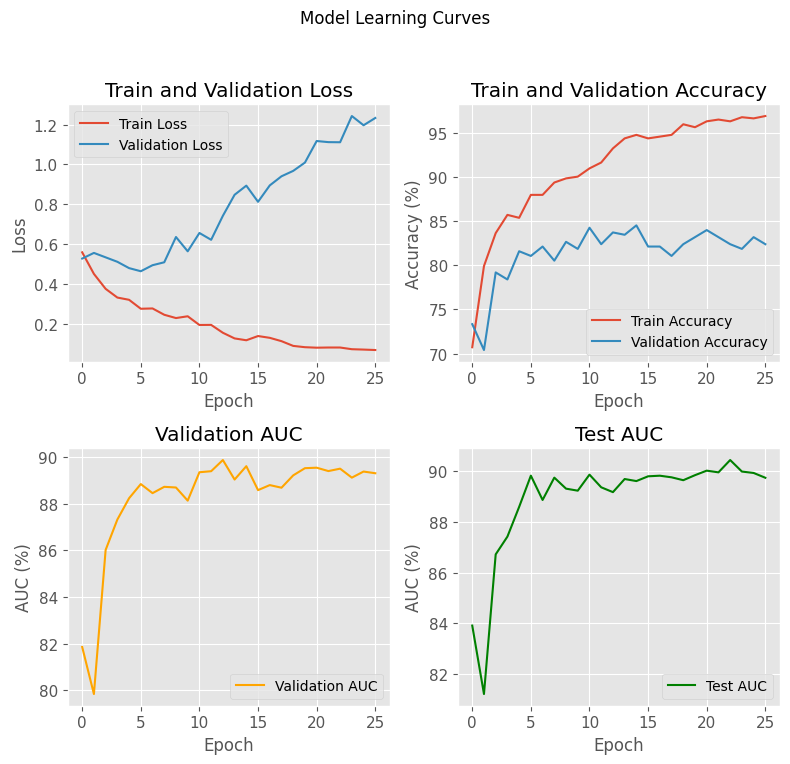

✅ 최종 평가 결과가 '/content/drive/MyDrive/Attentive_FP/Results/Corr/Final_result/final_result_2026-05-12_09-39-14.txt'에 저장되었습니다.

✅ 최종 테스트 데이터셋 평가 지표 (외부 검증 결과):
--------------------------------------------------
  loss      : 0.46%
  AUC       : 89.81%
  ACC       : 82.05%
  SE        : 70.00%
  SP        : 90.29%
  F1        : 76.00%
  MCC       : 62.42%
--------------------------------------------------

🔬 Confusion Matrix 생성...
✅ Confusion matrix가 '/content/drive/MyDrive/Attentive_FP/Results/Irrit/Confusion_matrix/Confusion_matrix_2026-05-12_09-39-14.png'에 저장되었습니다.


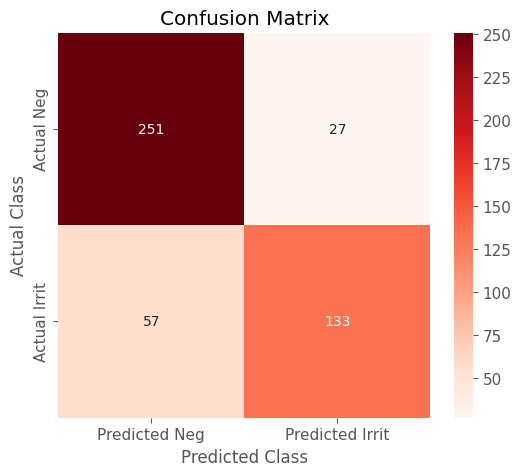


🔬 ROC Curve 생성...
✅ ROC Curve가 '/content/drive/MyDrive/Attentive_FP/Results/Irrit/ROC_curve/ROC_curve_2026-05-12_09-39-14.png'에 저장되었습니다.


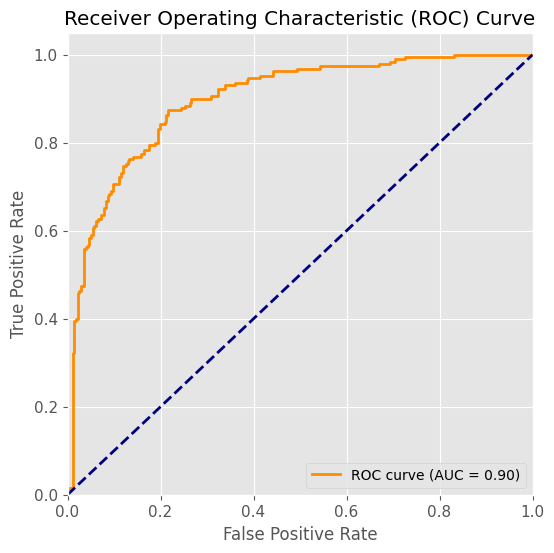

In [ ]:
# ===================================================================
# 3.4: 최종 모델 학습 및 평가 (Attention-Only: GNN_Extractor 단독)
# ===================================================================
run_timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
print(f"실행 ID: {run_timestamp}")
SUBFOLDER_FR = '/content/drive/MyDrive/Attentive_FP/Results/Corr/Final_result/'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"장치: {device}")

# GNN_Extractor 단독 초기화 (Attention-Only: HybridModel 미사용)
gnn_hidden_channels = best_params['hidden']
final_model = GNN_Extractor(
    hidden_channels=gnn_hidden_channels,
    out_channels=1,
    dropout=best_params['dropout']
).to(device)

optimizer = optim.Adam(final_model.parameters(), lr=best_params['lr'])
criterion = nn.BCEWithLogitsLoss()

train_subset, val_subset = train_test_split(train_dataset, test_size=0.2, random_state=42)
final_train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
final_val_loader   = DataLoader(val_subset,   batch_size=32)
test_loader        = DataLoader(test_dataset,  batch_size=32)

final_model, history = train_with_early_stopping(
    model=final_model,
    train_loader=final_train_loader,
    val_loader=final_val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=100,
    patience=20
)

plot_learning_curves(history)

final_metrics, y_true_final, y_pred_final, y_pred_proba_final = evaluate(
    final_model, test_loader, criterion, device
)

final_results_path = os.path.join(SUBFOLDER_FR, f"final_result_attnonly_{run_timestamp}.txt")
with open(final_results_path, 'w') as f:
    with redirect_stdout(f):
        print("Attention-Only 최종 평가 지표:")
        for name, value in final_metrics.items():
            print(f"  {name:<10s}: {format_metric(value)}%")

print(f"결과 저장: {final_results_path}")
print("\nAttention-Only 최종 평가 지표:")
for name, value in final_metrics.items():
    print(f"  {name:<10s}: {value:.2f}%")

plot_confusion_matrix(y_true_final, y_pred_final)
plot_roc_curve(y_true_final, y_pred_proba_final)


###3.5 AD 상세 분석

이번 실행의 고유 ID: 2026-05-12_09-39-35

--- AD 상세 분석 시작 ---


Z-값 변경하며 AD 분석 중:   0%|          | 0/11 [00:00<?, ?it/s]

[09:39:35] WARNING: not removing hydrogen atom without neighbors
[09:39:35] WARNING: not removing hydrogen atom without neighbors
[09:39:48] WARNING: not removing hydrogen atom without neighbors
[09:39:48] WARNING: not removing hydrogen atom without neighbors
[09:40:01] WARNING: not removing hydrogen atom without neighbors
[09:40:01] WARNING: not removing hydrogen atom without neighbors
[09:40:14] WARNING: not removing hydrogen atom without neighbors
[09:40:14] WARNING: not removing hydrogen atom without neighbors
[09:40:26] WARNING: not removing hydrogen atom without neighbors
[09:40:26] WARNING: not removing hydrogen atom without neighbors
[09:40:39] WARNING: not removing hydrogen atom without neighbors
[09:40:39] WARNING: not removing hydrogen atom without neighbors
[09:40:52] WARNING: not removing hydrogen atom without neighbors
[09:40:52] WARNING: not removing hydrogen atom without neighbors
[09:41:05] WARNING: not removing hydrogen atom without neighbors
[09:41:05] WARNING: not r


📊 적용 범위(AD) 상세 분석 결과표


,Z,ST,AD coverage (%),AUC (%) (Inside),AUC (%) (Outside)
0,0.6,0.718,71.795,93.657,79.229
1,0.7,0.705,75.855,93.734,76.383
2,0.8,0.691,78.205,93.624,75.702
3,0.9,0.678,80.556,93.629,72.576
4,1.0,0.664,83.120,93.092,72.517
5,1.1,0.650,84.615,92.786,72.222
6,1.2,0.637,86.752,92.474,70.899
7,1.3,0.623,88.889,92.533,66.667
8,1.4,0.610,91.026,92.321,62.824
9,1.5,0.596,94.231,91.453,61.184


✅ AD 분석 표가 '/content/drive/MyDrive/Attentive_FP/Results/Corr/AD_analysis/AD_analysis_2026-05-12_09-39-35.csv'에 저장되었습니다.

📈 논문 Figure 형식 그래프 생성 중...
✅ AD 논문용 그래프가 '/content/drive/MyDrive/Attentive_FP/Results/Corr/AD_analysis/AD_Figure3_2026-05-12_09-39-35.png'에 저장되었습니다.


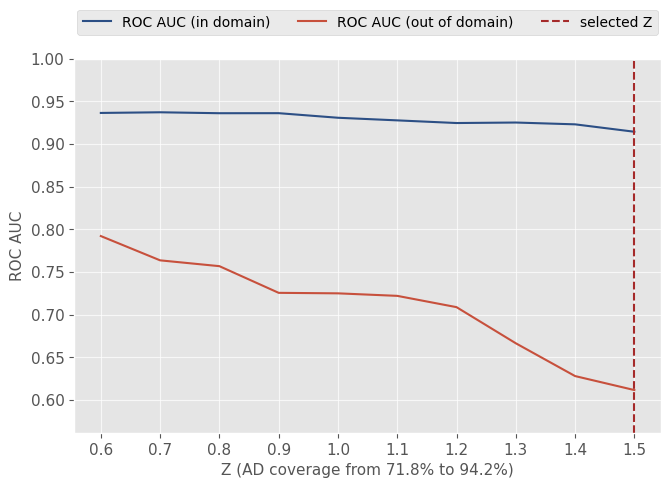

In [ ]:
run_timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
print(f"이번 실행의 고유 ID: {run_timestamp}")
RESULTS_AD_analysis = '/content/drive/MyDrive/Attentive_FP/Results/Corr/AD_analysis/'

print("\n--- AD 상세 분석 시작 ---")
try:
    # AD 상세 분석 함수 호출
    ad_analysis_table = analyze_applicability_domain(
        model=final_hybrid_model,
        train_dataset=train_dataset,
        test_dataset=test_dataset,
        device=device
    )

    # 결과가 성공적으로 생성되었을 때
    if ad_analysis_table is not None and not ad_analysis_table.empty:
        print("\n📊 적용 범위(AD) 상세 분석 결과표")
        display(ad_analysis_table.round(3))

        # 1. CSV 저장
        csv_save_path = os.path.join(RESULTS_AD_analysis, f"AD_analysis_{run_timestamp}.csv")
        ad_analysis_table.to_csv(csv_save_path, index=False)
        print(f"✅ AD 분석 표가 '{csv_save_path}'에 저장되었습니다.")

        # 2. ✨✨ 논문용 그래프 생성 및 저장 ✨✨
        img_save_path = os.path.join(RESULTS_AD_analysis, f"AD_Figure3_{run_timestamp}.png")
        print("\n📈 논문 Figure 형식 그래프 생성 중...")
        plot_ad_analysis(ad_analysis_table, save_path=img_save_path)

    else:
        print("\n⚠️ 분석을 완료했으나, 표/그래프로 만들 조건을 만족하는 결과가 없습니다.")

except Exception as e:
    print("\n" + "="*50)
    print("❌ AD 분석 중 예측하지 못한 오류 발생!")
    print("="*50)
    import traceback
    traceback.print_exc()
    print("="*50)

###3.6 결과 상세 해석 및 시각화

테스트 데이터셋 전체(468개)에 대해 예측을 수행합니다...


분자 예측 중:   0%|          | 0/468 [00:00<?, ?it/s]



[결과] 가장 높은 독성 확률을 가진 상위 10개 분자 📈

--- 상위 1번째 (예측 확률: 0.9995) ---
✅ 상세 해석 리포트가 '/content/drive/MyDrive/Attentive_FP/Results/Corr/visualize_attention/Run_2026-05-12_08-07-56/top_1_report.txt'에 저장되었습니다.
✅ 어텐션 맵 그림이 '/content/drive/MyDrive/Attentive_FP/Results/Corr/visualize_attention/Run_2026-05-12_08-07-56/top_1_attention_map.png'에 저장되었습니다.


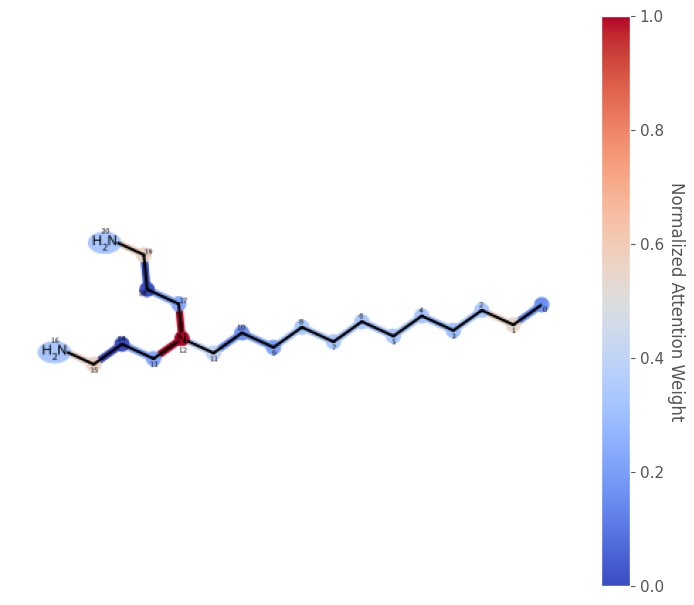


--- 상위 2번째 (예측 확률: 0.9994) ---
✅ 상세 해석 리포트가 '/content/drive/MyDrive/Attentive_FP/Results/Corr/visualize_attention/Run_2026-05-12_08-07-56/top_2_report.txt'에 저장되었습니다.
✅ 어텐션 맵 그림이 '/content/drive/MyDrive/Attentive_FP/Results/Corr/visualize_attention/Run_2026-05-12_08-07-56/top_2_attention_map.png'에 저장되었습니다.


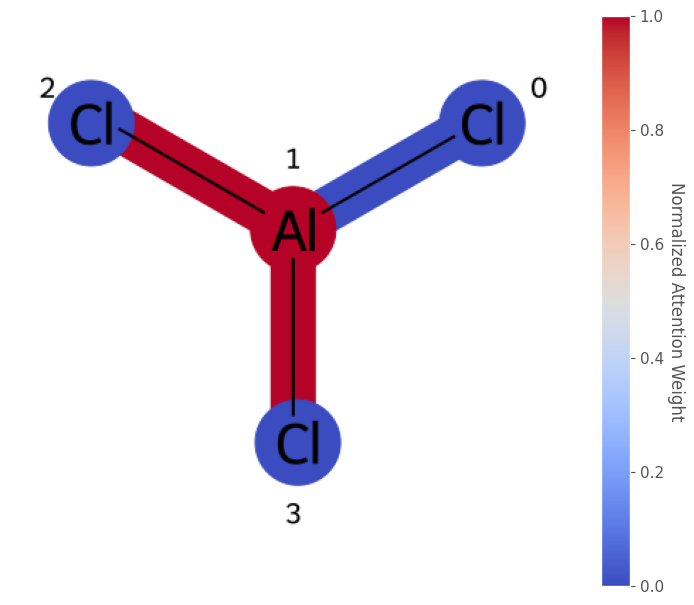


--- 상위 3번째 (예측 확률: 0.9987) ---
✅ 상세 해석 리포트가 '/content/drive/MyDrive/Attentive_FP/Results/Corr/visualize_attention/Run_2026-05-12_08-07-56/top_3_report.txt'에 저장되었습니다.
✅ 어텐션 맵 그림이 '/content/drive/MyDrive/Attentive_FP/Results/Corr/visualize_attention/Run_2026-05-12_08-07-56/top_3_attention_map.png'에 저장되었습니다.


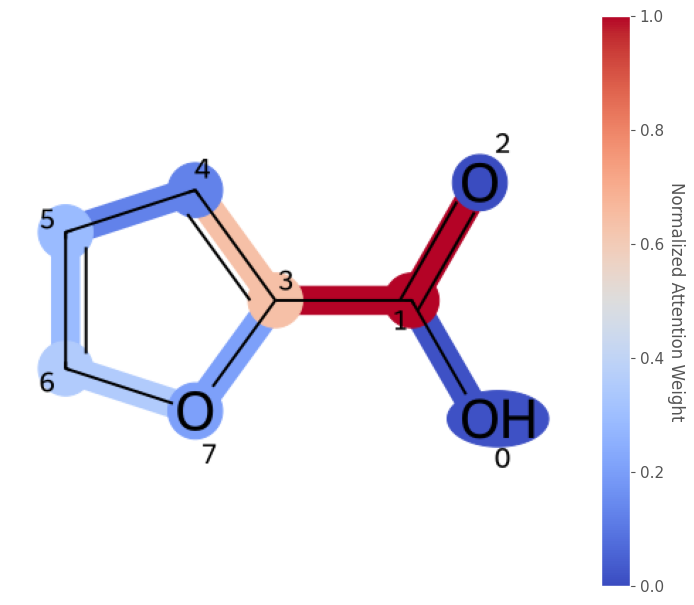


--- 상위 4번째 (예측 확률: 0.9984) ---
✅ 상세 해석 리포트가 '/content/drive/MyDrive/Attentive_FP/Results/Corr/visualize_attention/Run_2026-05-12_08-07-56/top_4_report.txt'에 저장되었습니다.
✅ 어텐션 맵 그림이 '/content/drive/MyDrive/Attentive_FP/Results/Corr/visualize_attention/Run_2026-05-12_08-07-56/top_4_attention_map.png'에 저장되었습니다.


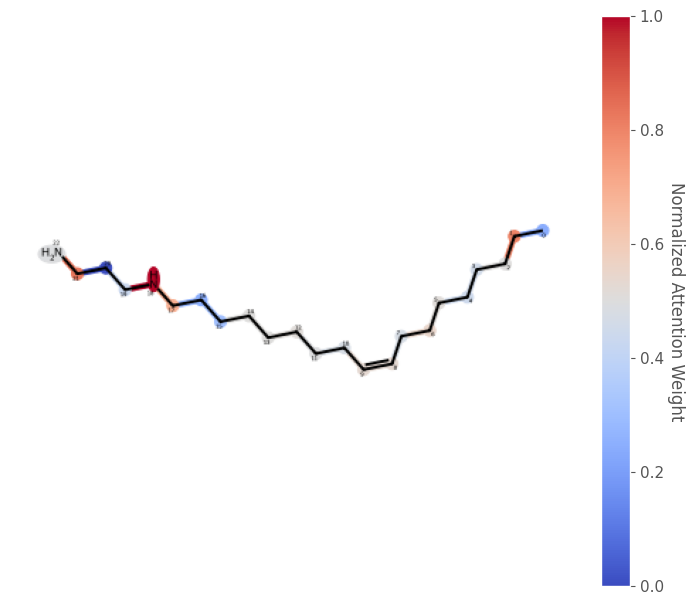


--- 상위 5번째 (예측 확률: 0.9984) ---
✅ 상세 해석 리포트가 '/content/drive/MyDrive/Attentive_FP/Results/Corr/visualize_attention/Run_2026-05-12_08-07-56/top_5_report.txt'에 저장되었습니다.
✅ 어텐션 맵 그림이 '/content/drive/MyDrive/Attentive_FP/Results/Corr/visualize_attention/Run_2026-05-12_08-07-56/top_5_attention_map.png'에 저장되었습니다.


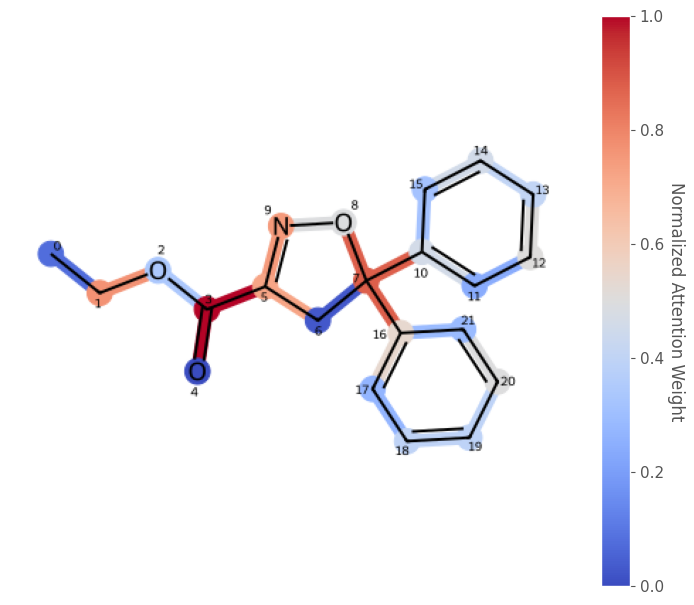


--- 상위 6번째 (예측 확률: 0.9984) ---
✅ 상세 해석 리포트가 '/content/drive/MyDrive/Attentive_FP/Results/Corr/visualize_attention/Run_2026-05-12_08-07-56/top_6_report.txt'에 저장되었습니다.
✅ 어텐션 맵 그림이 '/content/drive/MyDrive/Attentive_FP/Results/Corr/visualize_attention/Run_2026-05-12_08-07-56/top_6_attention_map.png'에 저장되었습니다.


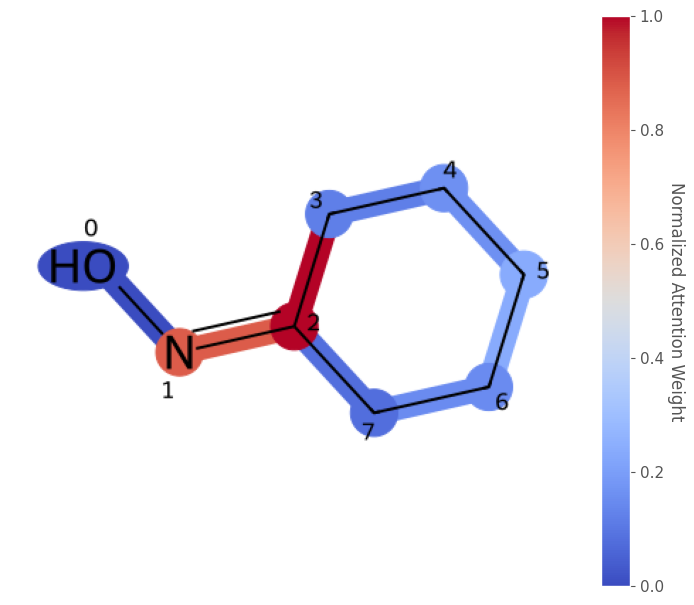


--- 상위 7번째 (예측 확률: 0.9972) ---
✅ 상세 해석 리포트가 '/content/drive/MyDrive/Attentive_FP/Results/Corr/visualize_attention/Run_2026-05-12_08-07-56/top_7_report.txt'에 저장되었습니다.
✅ 어텐션 맵 그림이 '/content/drive/MyDrive/Attentive_FP/Results/Corr/visualize_attention/Run_2026-05-12_08-07-56/top_7_attention_map.png'에 저장되었습니다.


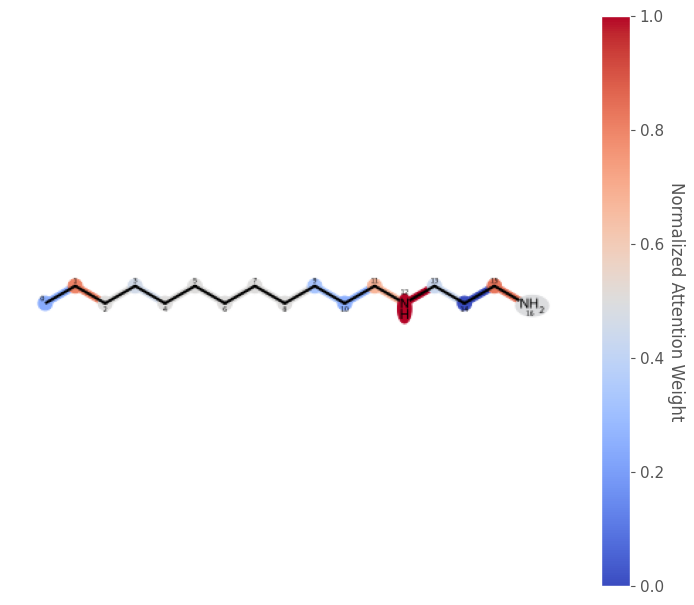


--- 상위 8번째 (예측 확률: 0.9965) ---
✅ 상세 해석 리포트가 '/content/drive/MyDrive/Attentive_FP/Results/Corr/visualize_attention/Run_2026-05-12_08-07-56/top_8_report.txt'에 저장되었습니다.
✅ 어텐션 맵 그림이 '/content/drive/MyDrive/Attentive_FP/Results/Corr/visualize_attention/Run_2026-05-12_08-07-56/top_8_attention_map.png'에 저장되었습니다.


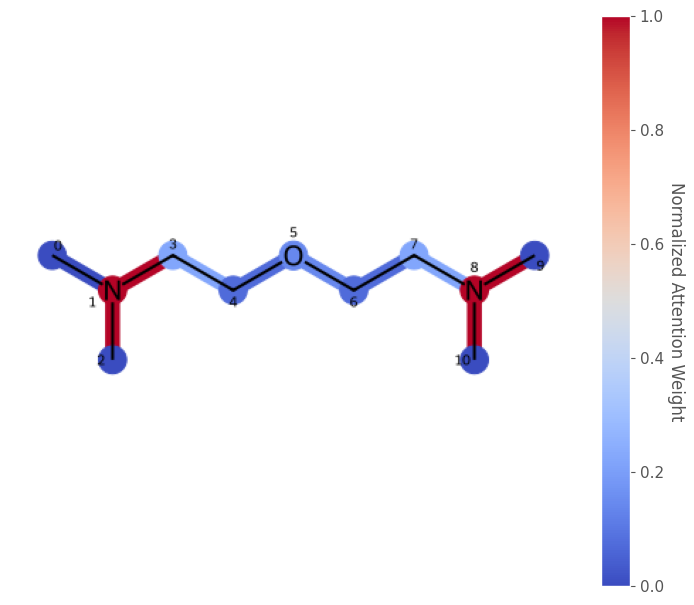


--- 상위 9번째 (예측 확률: 0.9962) ---
✅ 상세 해석 리포트가 '/content/drive/MyDrive/Attentive_FP/Results/Corr/visualize_attention/Run_2026-05-12_08-07-56/top_9_report.txt'에 저장되었습니다.
✅ 어텐션 맵 그림이 '/content/drive/MyDrive/Attentive_FP/Results/Corr/visualize_attention/Run_2026-05-12_08-07-56/top_9_attention_map.png'에 저장되었습니다.


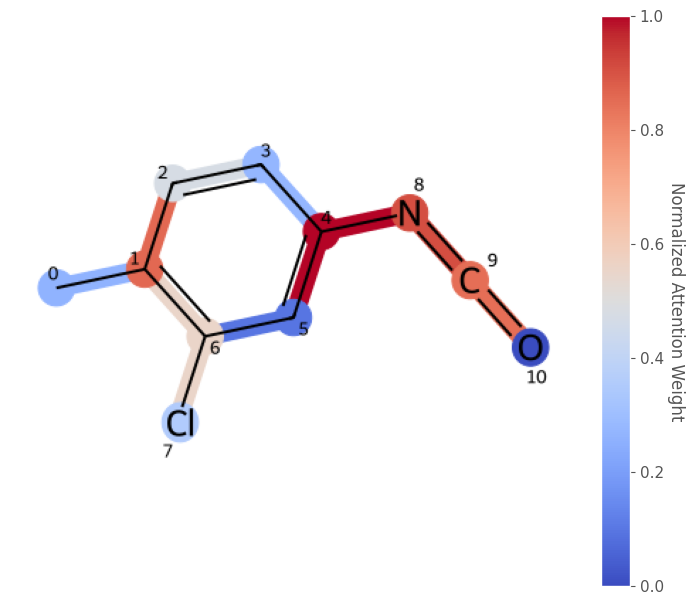


--- 상위 10번째 (예측 확률: 0.9961) ---
✅ 상세 해석 리포트가 '/content/drive/MyDrive/Attentive_FP/Results/Corr/visualize_attention/Run_2026-05-12_08-07-56/top_10_report.txt'에 저장되었습니다.
✅ 어텐션 맵 그림이 '/content/drive/MyDrive/Attentive_FP/Results/Corr/visualize_attention/Run_2026-05-12_08-07-56/top_10_attention_map.png'에 저장되었습니다.


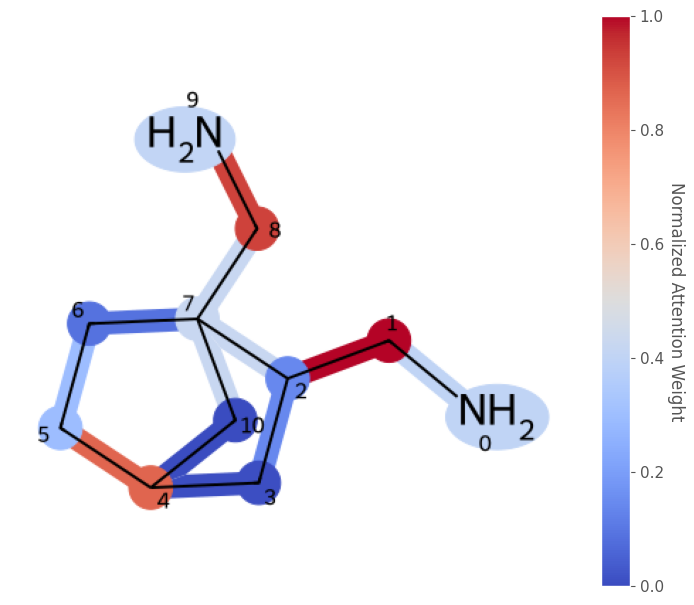


[결과] 가장 낮은 독성 확률을 가진 상위 10개 분자 📉

--- 하위 1번째 (예측 확률: 0.0000) ---
✅ 상세 해석 리포트가 '/content/drive/MyDrive/Attentive_FP/Results/Corr/visualize_attention/Run_2026-05-12_08-07-56/bottom_1_report.txt'에 저장되었습니다.
✅ 어텐션 맵 그림이 '/content/drive/MyDrive/Attentive_FP/Results/Corr/visualize_attention/Run_2026-05-12_08-07-56/bottom_1_attention_map.png'에 저장되었습니다.


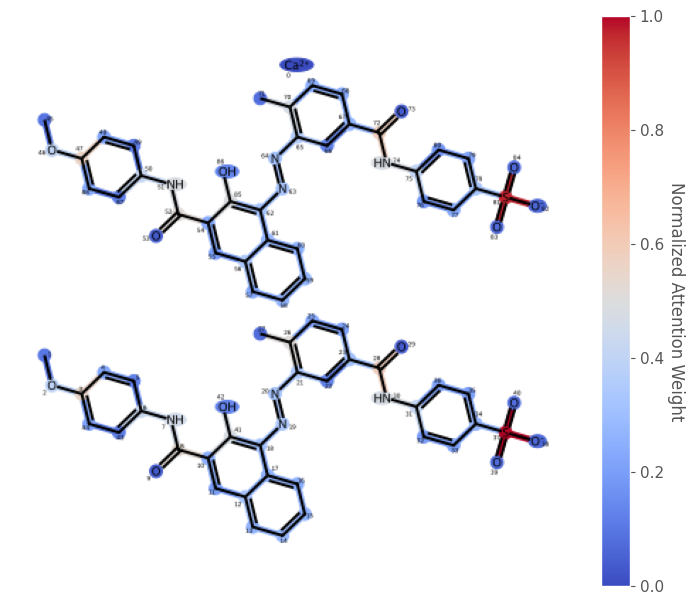


--- 하위 2번째 (예측 확률: 0.0000) ---
✅ 상세 해석 리포트가 '/content/drive/MyDrive/Attentive_FP/Results/Corr/visualize_attention/Run_2026-05-12_08-07-56/bottom_2_report.txt'에 저장되었습니다.
✅ 어텐션 맵 그림이 '/content/drive/MyDrive/Attentive_FP/Results/Corr/visualize_attention/Run_2026-05-12_08-07-56/bottom_2_attention_map.png'에 저장되었습니다.


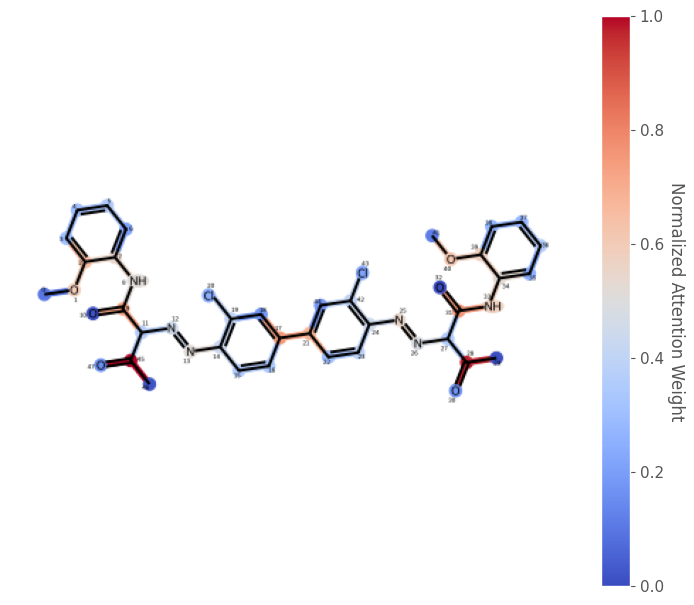


--- 하위 3번째 (예측 확률: 0.0000) ---
✅ 상세 해석 리포트가 '/content/drive/MyDrive/Attentive_FP/Results/Corr/visualize_attention/Run_2026-05-12_08-07-56/bottom_3_report.txt'에 저장되었습니다.
✅ 어텐션 맵 그림이 '/content/drive/MyDrive/Attentive_FP/Results/Corr/visualize_attention/Run_2026-05-12_08-07-56/bottom_3_attention_map.png'에 저장되었습니다.


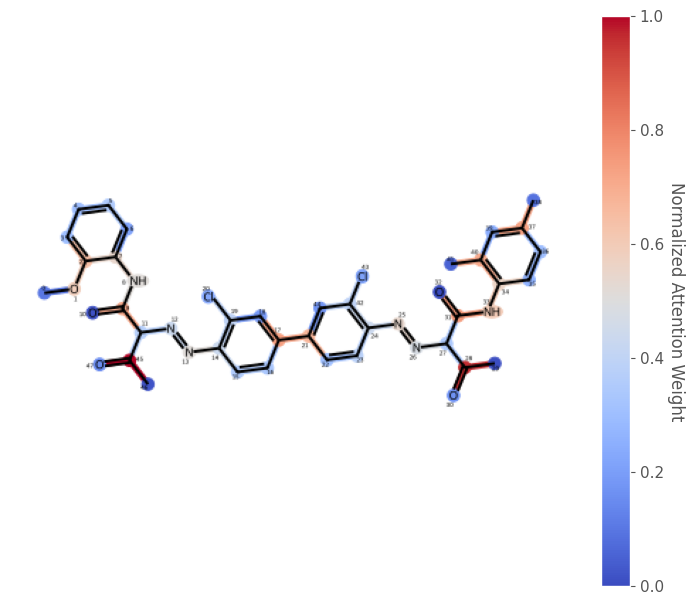


--- 하위 4번째 (예측 확률: 0.0000) ---
✅ 상세 해석 리포트가 '/content/drive/MyDrive/Attentive_FP/Results/Corr/visualize_attention/Run_2026-05-12_08-07-56/bottom_4_report.txt'에 저장되었습니다.
✅ 어텐션 맵 그림이 '/content/drive/MyDrive/Attentive_FP/Results/Corr/visualize_attention/Run_2026-05-12_08-07-56/bottom_4_attention_map.png'에 저장되었습니다.


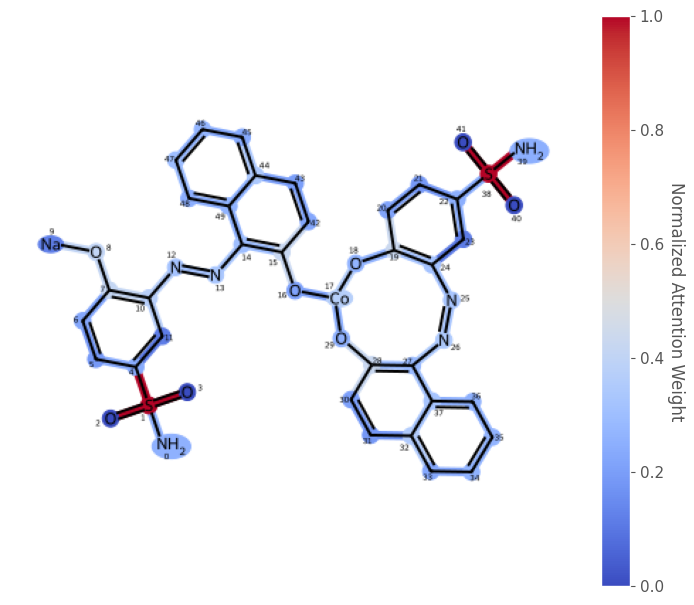


--- 하위 5번째 (예측 확률: 0.0000) ---
✅ 상세 해석 리포트가 '/content/drive/MyDrive/Attentive_FP/Results/Corr/visualize_attention/Run_2026-05-12_08-07-56/bottom_5_report.txt'에 저장되었습니다.
✅ 어텐션 맵 그림이 '/content/drive/MyDrive/Attentive_FP/Results/Corr/visualize_attention/Run_2026-05-12_08-07-56/bottom_5_attention_map.png'에 저장되었습니다.


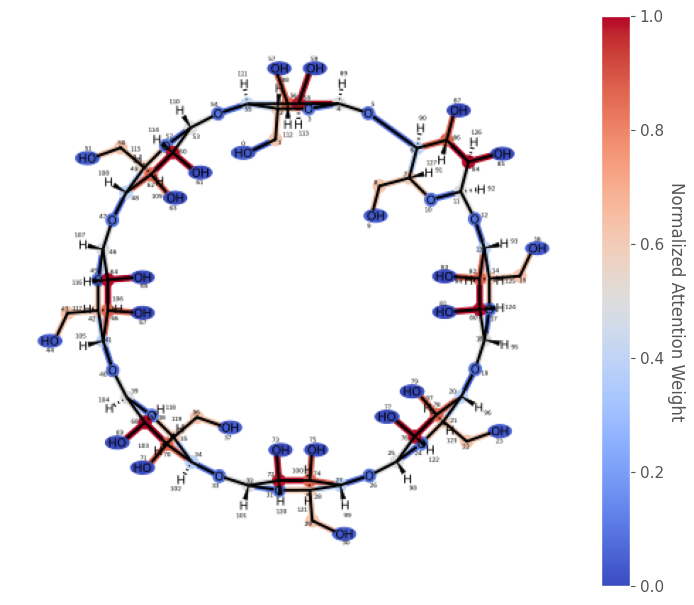


--- 하위 6번째 (예측 확률: 0.0000) ---
✅ 상세 해석 리포트가 '/content/drive/MyDrive/Attentive_FP/Results/Corr/visualize_attention/Run_2026-05-12_08-07-56/bottom_6_report.txt'에 저장되었습니다.
✅ 어텐션 맵 그림이 '/content/drive/MyDrive/Attentive_FP/Results/Corr/visualize_attention/Run_2026-05-12_08-07-56/bottom_6_attention_map.png'에 저장되었습니다.


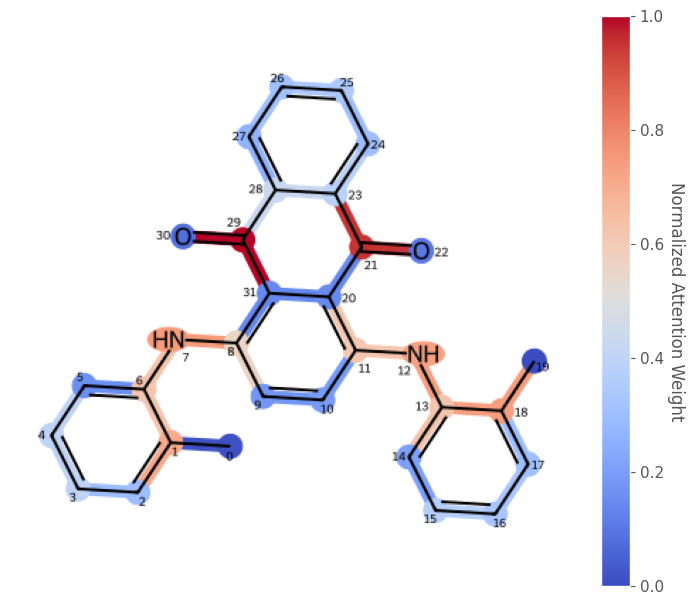


--- 하위 7번째 (예측 확률: 0.0000) ---
✅ 상세 해석 리포트가 '/content/drive/MyDrive/Attentive_FP/Results/Corr/visualize_attention/Run_2026-05-12_08-07-56/bottom_7_report.txt'에 저장되었습니다.
✅ 어텐션 맵 그림이 '/content/drive/MyDrive/Attentive_FP/Results/Corr/visualize_attention/Run_2026-05-12_08-07-56/bottom_7_attention_map.png'에 저장되었습니다.


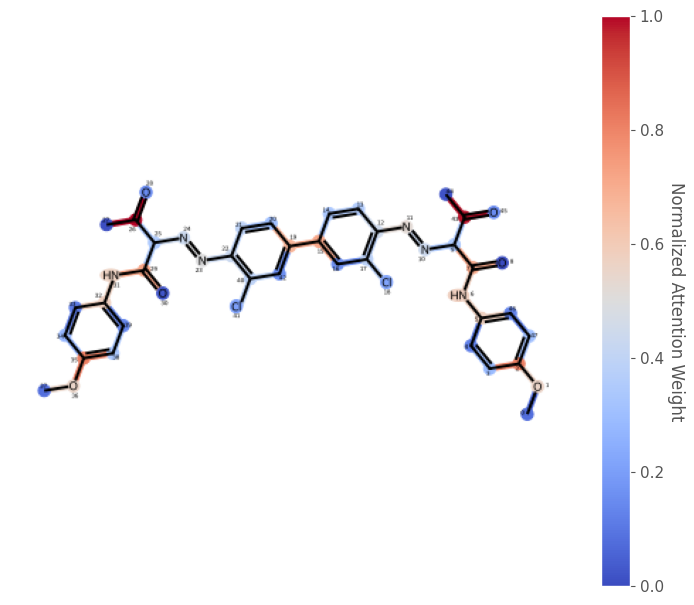


--- 하위 8번째 (예측 확률: 0.0000) ---
✅ 상세 해석 리포트가 '/content/drive/MyDrive/Attentive_FP/Results/Corr/visualize_attention/Run_2026-05-12_08-07-56/bottom_8_report.txt'에 저장되었습니다.
✅ 어텐션 맵 그림이 '/content/drive/MyDrive/Attentive_FP/Results/Corr/visualize_attention/Run_2026-05-12_08-07-56/bottom_8_attention_map.png'에 저장되었습니다.


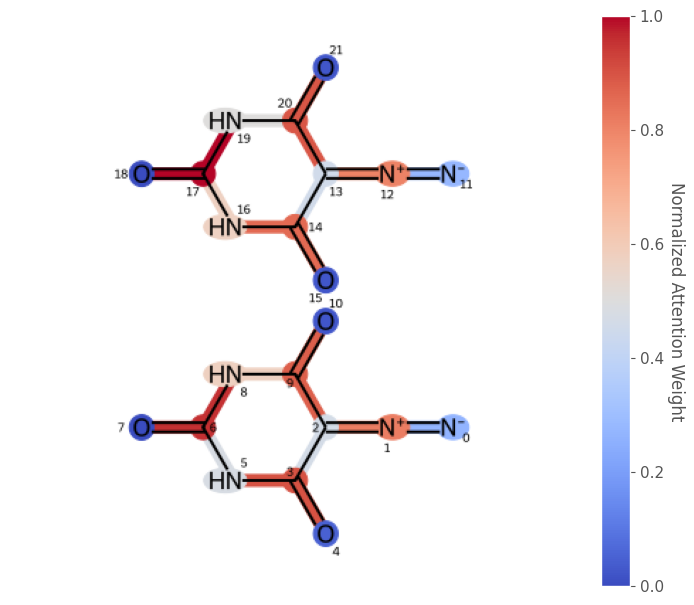


--- 하위 9번째 (예측 확률: 0.0000) ---
✅ 상세 해석 리포트가 '/content/drive/MyDrive/Attentive_FP/Results/Corr/visualize_attention/Run_2026-05-12_08-07-56/bottom_9_report.txt'에 저장되었습니다.
✅ 어텐션 맵 그림이 '/content/drive/MyDrive/Attentive_FP/Results/Corr/visualize_attention/Run_2026-05-12_08-07-56/bottom_9_attention_map.png'에 저장되었습니다.


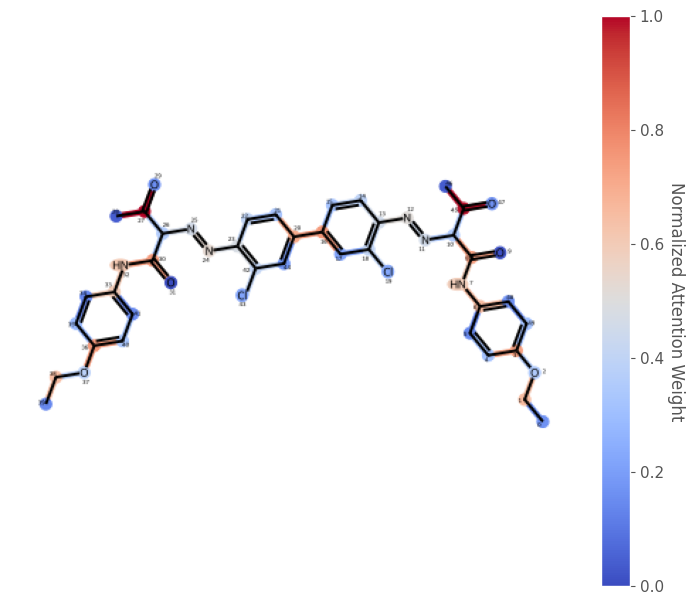


--- 하위 10번째 (예측 확률: 0.0000) ---
✅ 상세 해석 리포트가 '/content/drive/MyDrive/Attentive_FP/Results/Corr/visualize_attention/Run_2026-05-12_08-07-56/bottom_10_report.txt'에 저장되었습니다.
✅ 어텐션 맵 그림이 '/content/drive/MyDrive/Attentive_FP/Results/Corr/visualize_attention/Run_2026-05-12_08-07-56/bottom_10_attention_map.png'에 저장되었습니다.


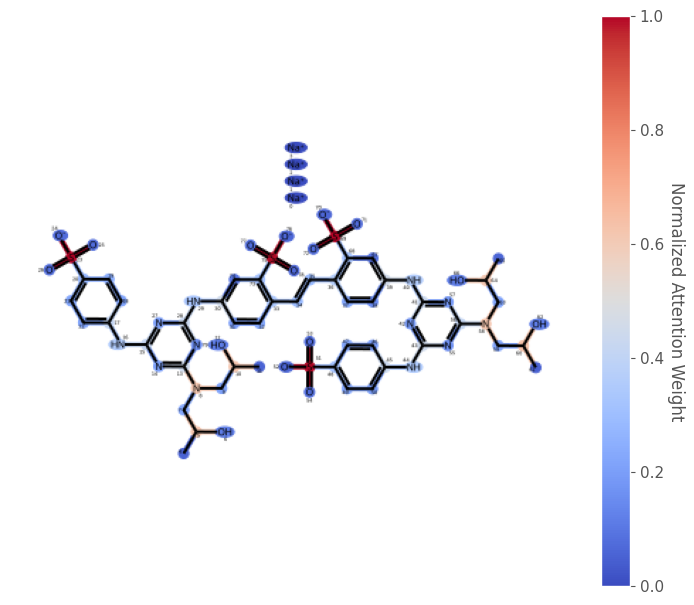

In [ ]:
find_and_visualize_extreme_predictions(
    model=final_hybrid_model,
    dataset=test_dataset,
    train_fps=train_fingerprints,
    threshold_S=ad_threshold,
    fp_function=smiles_to_maccs_fp,
    scaler=descriptor_scaler
)

### 3.7 구조적 경고 탐색 (통계 분석)

[완화 탐색] 양성: 962개 | 음성: 1394개
[조건] p<0.1, accuracy>0.55, pos_freq>=2, neg_freq<20
[INFO] 반경 1 탐색 중...


[12:31:50] DEPRECATION WARNING: please use MorganGenerator
[12:31:50] DEPRECATION WARNING: please use MorganGenerator
[12:31:50] DEPRECATION WARNING: please use MorganGenerator
[12:31:50] DEPRECATION WARNING: please use MorganGenerator
[12:31:50] DEPRECATION WARNING: please use MorganGenerator
[12:31:50] DEPRECATION WARNING: please use MorganGenerator
[12:31:50] DEPRECATION WARNING: please use MorganGenerator
[12:31:50] DEPRECATION WARNING: please use MorganGenerator
[12:31:50] DEPRECATION WARNING: please use MorganGenerator
[12:31:50] DEPRECATION WARNING: please use MorganGenerator
[12:31:50] DEPRECATION WARNING: please use MorganGenerator
[12:31:50] DEPRECATION WARNING: please use MorganGenerator
[12:31:50] DEPRECATION WARNING: please use MorganGenerator
[12:31:50] DEPRECATION WARNING: please use MorganGenerator
[12:31:50] DEPRECATION WARNING: please use MorganGenerator
[12:31:50] DEPRECATION WARNING: please use MorganGenerator
[12:31:50] DEPRECATION WARNING: please use MorganGenerat

[INFO] 반경 2 탐색 중...


[12:31:54] DEPRECATION WARNING: please use MorganGenerator
[12:31:54] DEPRECATION WARNING: please use MorganGenerator
[12:31:54] DEPRECATION WARNING: please use MorganGenerator
[12:31:54] DEPRECATION WARNING: please use MorganGenerator
[12:31:54] DEPRECATION WARNING: please use MorganGenerator
[12:31:54] DEPRECATION WARNING: please use MorganGenerator
[12:31:54] DEPRECATION WARNING: please use MorganGenerator
[12:31:54] DEPRECATION WARNING: please use MorganGenerator
[12:31:54] DEPRECATION WARNING: please use MorganGenerator
[12:31:54] DEPRECATION WARNING: please use MorganGenerator
[12:31:54] DEPRECATION WARNING: please use MorganGenerator
[12:31:54] DEPRECATION WARNING: please use MorganGenerator
[12:31:54] DEPRECATION WARNING: please use MorganGenerator
[12:31:54] DEPRECATION WARNING: please use MorganGenerator
[12:31:54] DEPRECATION WARNING: please use MorganGenerator
[12:31:54] DEPRECATION WARNING: please use MorganGenerator
[12:31:54] DEPRECATION WARNING: please use MorganGenerat

[INFO] 반경 3 탐색 중...


[12:31:58] DEPRECATION WARNING: please use MorganGenerator
[12:31:58] DEPRECATION WARNING: please use MorganGenerator
[12:31:58] DEPRECATION WARNING: please use MorganGenerator
[12:31:58] DEPRECATION WARNING: please use MorganGenerator
[12:31:58] DEPRECATION WARNING: please use MorganGenerator
[12:31:58] DEPRECATION WARNING: please use MorganGenerator
[12:31:58] DEPRECATION WARNING: please use MorganGenerator
[12:31:58] DEPRECATION WARNING: please use MorganGenerator
[12:31:59] DEPRECATION WARNING: please use MorganGenerator
[12:31:59] DEPRECATION WARNING: please use MorganGenerator
[12:31:59] DEPRECATION WARNING: please use MorganGenerator
[12:31:59] DEPRECATION WARNING: please use MorganGenerator
[12:31:59] DEPRECATION WARNING: please use MorganGenerator
[12:31:59] DEPRECATION WARNING: please use MorganGenerator
[12:31:59] DEPRECATION WARNING: please use MorganGenerator
[12:31:59] DEPRECATION WARNING: please use MorganGenerator
[12:31:59] DEPRECATION WARNING: please use MorganGenerat

[INFO] 반경 4 탐색 중...


[12:32:03] DEPRECATION WARNING: please use MorganGenerator
[12:32:03] DEPRECATION WARNING: please use MorganGenerator
[12:32:03] DEPRECATION WARNING: please use MorganGenerator
[12:32:03] DEPRECATION WARNING: please use MorganGenerator
[12:32:03] DEPRECATION WARNING: please use MorganGenerator
[12:32:03] DEPRECATION WARNING: please use MorganGenerator
[12:32:03] DEPRECATION WARNING: please use MorganGenerator
[12:32:03] DEPRECATION WARNING: please use MorganGenerator
[12:32:03] DEPRECATION WARNING: please use MorganGenerator
[12:32:03] DEPRECATION WARNING: please use MorganGenerator
[12:32:03] DEPRECATION WARNING: please use MorganGenerator
[12:32:03] DEPRECATION WARNING: please use MorganGenerator
[12:32:03] DEPRECATION WARNING: please use MorganGenerator
[12:32:03] DEPRECATION WARNING: please use MorganGenerator
[12:32:03] DEPRECATION WARNING: please use MorganGenerator
[12:32:03] DEPRECATION WARNING: please use MorganGenerator
[12:32:03] DEPRECATION WARNING: please use MorganGenerat


[진단] 필터 전 전체 후보: 22703개
  p < 0.1          : 402개
  pos_freq >= 2      : 1534개
  neg_freq < 20       : 22482개
  accuracy > 0.55   : 22678개

[결과] 완화 기준 통과 후보: 391개


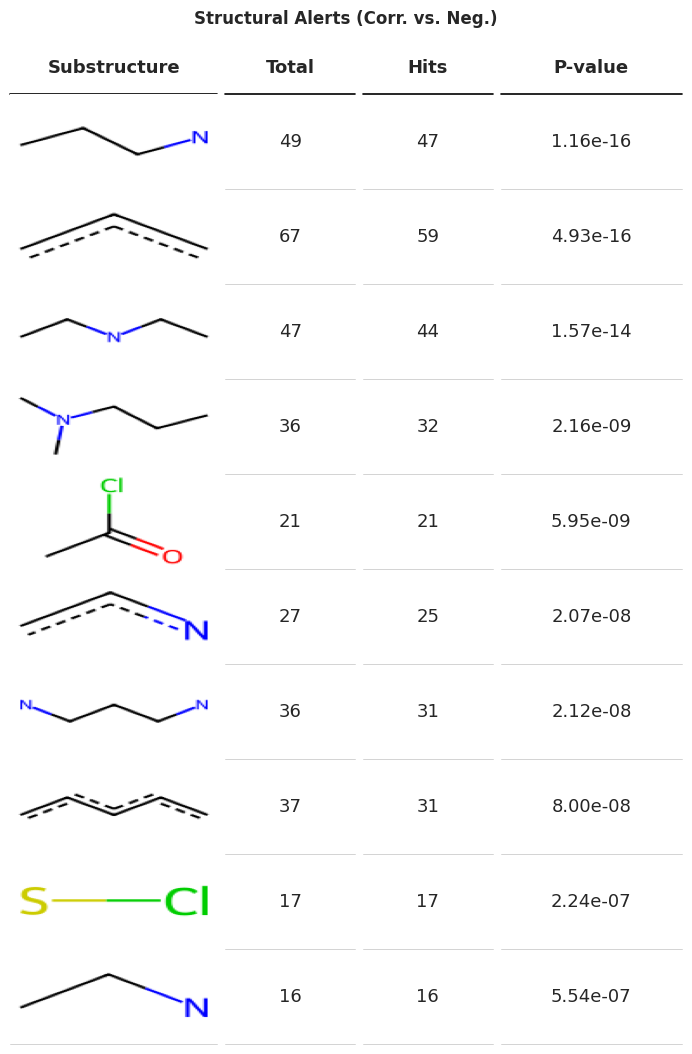

저장 완료: /content/drive/MyDrive/Attentive_FP/Results/Corr/Structure_alerts/Table4_structural_alerts.png


In [ ]:
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw
import os

RESULTS_Structure_alerts = '/content/drive/MyDrive/Attentive_FP/Results/Corr/Structure_alerts/'
os.makedirs(RESULTS_Structure_alerts, exist_ok=True)

raw_result = run_structural_alert_analysis_relaxed(
    df, p_thresh=0.1, acc_thresh=0.55, min_pos_freq=2, max_neg_freq=20, top_n=10
)

if raw_result is None:
    print("구조적 경고 후보가 없습니다.")
else:
    tdf = raw_result.copy().reset_index(drop=True)
    tdf['Total']   = tdf['positive_freq'] + tdf['negative_freq']
    tdf['Hits']    = tdf['positive_freq']
    tdf['P-value'] = tdf['p_value'].apply(lambda x: f"{x:.2e}")
    n = len(tdf)

    row_h  = 1.0
    head_h = 0.45
    fig_h  = head_h + row_h * n
    fig_w  = 7.0

    fig = plt.figure(figsize=(fig_w, fig_h), facecolor='white', dpi=100)
    gs = GridSpec(
        n + 1, 4,
        figure=fig,
        height_ratios=[head_h] + [row_h] * n,
        width_ratios=[1.6, 1, 1, 1.4],
        hspace=0.0, wspace=0.05,
        top=0.97, bottom=0.02, left=0.02, right=0.98
    )

    headers = ['Substructure', 'Total', 'Hits', 'P-value']

    # 헤더 행
    for ci, hdr in enumerate(headers):
        ax_h = fig.add_subplot(gs[0, ci])
        ax_h.set_xlim(0, 1)
        ax_h.set_ylim(0, 1)
        ax_h.axis('off')
        ax_h.text(0.5, 0.4, hdr, ha='center', va='bottom',
                  fontsize=13, fontweight='bold')
        # transform 없이 data 좌표로 선 그리기
        ax_h.plot([0, 1], [0, 0], color='black', linewidth=1.2,
                  transform=ax_h.transAxes, clip_on=False)

    # 데이터 행
    for ri in range(n):
        # 분자 이미지
        ax_img = fig.add_subplot(gs[ri + 1, 0])
        ax_img.set_xlim(0, 1)
        ax_img.set_ylim(0, 1)
        ax_img.axis('off')
        ax_img.plot([0, 1], [0, 0], color='#cccccc', linewidth=0.6,
                    transform=ax_img.transAxes, clip_on=False)
        try:
            mol = Chem.MolFromSmarts(tdf.loc[ri, 'SMARTS'])
            if mol is not None:
                img = Draw.MolToImage(mol, size=(120, 85), kekulize=False)
                ax_img.imshow(np.array(img), extent=[0, 1, 0, 1],
                              aspect='auto', zorder=2)
        except Exception as e:
            print(f"Row {ri} 이미지 오류: {e} | SMARTS: {tdf.loc[ri, 'SMARTS'][:50]}")
            ax_img.text(0.5, 0.5, 'N/A', ha='center', va='center', fontsize=9)

        # 텍스트 셀
        for ci, col in enumerate(['Total', 'Hits', 'P-value']):
            ax_t = fig.add_subplot(gs[ri + 1, ci + 1])
            ax_t.set_xlim(0, 1)
            ax_t.set_ylim(0, 1)
            ax_t.axis('off')
            ax_t.plot([0, 1], [0, 0], color='#cccccc', linewidth=0.6,
                      transform=ax_t.transAxes, clip_on=False)
            ax_t.text(0.5, 0.5, str(tdf.loc[ri, col]),
                      ha='center', va='center', fontsize=13)

    plt.suptitle('Structural Alerts (Corr. vs. Neg.)',
                 fontsize=12, fontweight='bold', y=1.01)

    save_path = os.path.join(RESULTS_Structure_alerts, 'Table4_structural_alerts.png')
    fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"저장 완료: {save_path}")


In [ ]:
run_timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
print(f"이번 실행의 고유 ID: {run_timestamp}")
SUBFOLDER_SHAP = '/content/drive/MyDrive/Attentive_FP/Results/Corr/SHAP/'

# --- 1단계: SHAP 분석을 위한 데이터 준비 ---

# 1a. 배경 데이터(background) 준비: 훈련 데이터셋에서 일부를 사용합니다.
#     SHAP은 이 배경 데이터를 기준으로 각 특징의 영향력을 계산합니다.
background_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)
background_batch = next(iter(background_loader))

# 1b. 설명할 데이터(explain) 준비: 테스트 데이터셋 전체 또는 일부를 사용합니다.
explain_loader = DataLoader(test_dataset, batch_size=200) # 예시로 200개 사용
explain_batch = next(iter(explain_loader))

# --- 2단계: SHAP Explainer 생성 및 shap_values 계산 ---

# 2a. SHAP은 numpy 배열을 입력받는 예측 함수를 기대하므로,
#     PyG Data 객체를 받아 예측을 수행하는 래퍼(wrapper) 함수를 만듭니다.
def predict_for_shap(descriptors_np):
    # 이 함수는 (샘플 수, 디스크립터 수) 모양의 numpy 배열을 입력받습니다.

    # 1. numpy 배열을 다시 PyG Data 객체 리스트로 변환
    data_list = []
    # 배경 데이터의 그래프 구조를 재활용하여 새로운 Data 객체를 만듭니다.
    for i in range(descriptors_np.shape[0]):
        data = train_dataset[0].clone() # 그래프 구조 복사 (x, edge_index 등)
        data.desc = torch.tensor(descriptors_np[i:i+1], dtype=torch.float)
        data_list.append(data)

    # 2. 미니배치 생성 및 모델 예측
    temp_loader = DataLoader(data_list, batch_size=32)
    predictions = []
    with torch.no_grad():
        for batch in temp_loader:
            pred = final_hybrid_model(batch.to(device))
            predictions.append(pred.cpu().numpy())

    return np.concatenate(predictions)

# 2b. KernelExplainer를 생성합니다. (모델 종류에 상관없이 사용 가능)
explainer = shap.KernelExplainer(predict_for_shap, background_batch.desc.cpu().numpy())

# 2c. 테스트 데이터에 대한 SHAP 값을 계산합니다. (시간이 가장 많이 소요되는 부분)
print("\n🔬 SHAP 값을 계산합니다... (데이터 양에 따라 시간이 소요될 수 있습니다)")
shap_values = explainer.shap_values(explain_batch.desc.cpu().numpy())
print("✅ SHAP 값 계산 완료!")

# --- 3단계: 결과 시각화 ---

# 3a. 설명 대상이 된 데이터의 디스크립터를 DataFrame으로 만듭니다.
test_desc_df = pd.DataFrame(explain_batch.desc.cpu().numpy(), columns=RDKIT_DESC_NAMES)

# 3b. (안전 장치) boolean 타입을 정수(0/1)로 변환
bool_cols = test_desc_df.select_dtypes(include='bool').columns
if len(bool_cols) > 0:
    test_desc_df[bool_cols] = test_desc_df[bool_cols].astype(int)

# 3c. SHAP 요약 플롯 생성
print("\n🔬 SHAP 특징 중요도 요약 플롯:")
# 1. show=False 옵션으로 SHAP 플롯 객체를 생성합니다.
shap.summary_plot(
    shap_values,
    features=test_desc_df,
    max_display=10,
    show=False # ◀️ 중요: 바로 보여주지 않도록 설정
)

# 2. 저장할 경로와 파일 이름을 지정합니다.
#    SUBFOLDER_PATH는 이전에 정의한 저장용 하위 폴더 경로입니다.
save_path = os.path.join(SUBFOLDER_SHAP, f"shap_summary_plot_{run_timestamp}.png")

# 3. plt.savefig()로 그래프를 저장합니다.
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✅ SHAP 요약 플롯이 '{save_path}'에 저장되었습니다.")

# 4. 화면에도 그래프를 보여줍니다.
plt.show()

# 5. 현재 figure를 닫아 다음 플롯에 영향을 주지 않도록 합니다.
plt.close()

이번 실행의 고유 ID: 2026-05-12_09-42-10

🔬 SHAP 값을 계산합니다... (데이터 양에 따라 시간이 소요될 수 있습니다)


  0%|          | 0/200 [00:00<?, ?it/s]

KeyboardInterrupt: 

### 3.8 데이터 분포 및 화학 공간 분석 (Chemical Space Analysis)
t-SNE를 활용하여 훈련 및 테스트 데이터셋의 분자들의 구조적 분포를 2차원 및 3차원 화학 공간에 시각화합니다.

**t-SNE (t-Distributed Stochastic Neighbor Embedding)**:
- 고차원 데이터(분자 지문)를 2~3차원으로 축소할 때, **가까이 있는 데이터(비슷한 분자)는 계속 가깝게 유지**하도록 맵핑하는 데 특화된 알고리즘입니다.
- 독성을 띠는 분자들이 특정 클러스터로 모이는지 시각적으로 확인하기 아주 좋습니다.

In [ ]:
# 고품질 시각화를 위한 패키지 설치
!pip install seaborn plotly

🔬 데이터 결합 및 Morgan Fingerprint 추출 중...


[10:09:29] DEPRECATION WARNING: please use MorganGenerator
[10:09:29] DEPRECATION WARNING: please use MorganGenerator
[10:09:29] DEPRECATION WARNING: please use MorganGenerator
[10:09:29] DEPRECATION WARNING: please use MorganGenerator
[10:09:29] DEPRECATION WARNING: please use MorganGenerator
[10:09:29] DEPRECATION WARNING: please use MorganGenerator
[10:09:29] DEPRECATION WARNING: please use MorganGenerator
[10:09:29] DEPRECATION WARNING: please use MorganGenerator
[10:09:29] DEPRECATION WARNING: please use MorganGenerator
[10:09:29] DEPRECATION WARNING: please use MorganGenerator
[10:09:29] DEPRECATION WARNING: please use MorganGenerator
[10:09:29] DEPRECATION WARNING: please use MorganGenerator
[10:09:29] DEPRECATION WARNING: please use MorganGenerator
[10:09:29] DEPRECATION WARNING: please use MorganGenerator
[10:09:29] DEPRECATION WARNING: please use MorganGenerator
[10:09:29] DEPRECATION WARNING: please use MorganGenerator
[10:09:29] DEPRECATION WARNING: please use MorganGenerat

✅ 총 2356개의 분자에서 Fingerprint 추출 완료!
🔄 t-SNE 2D 및 3D 좌표 계산 중... (수 분이 소요될 수 있습니다)
✅ t-SNE 계산 완료!
✅ 2D t-SNE 플롯 저장 완료: /content/drive/MyDrive/Attentive_FP/Results/Corr/ChemicalSpace/tSNE_2D_Plot.png


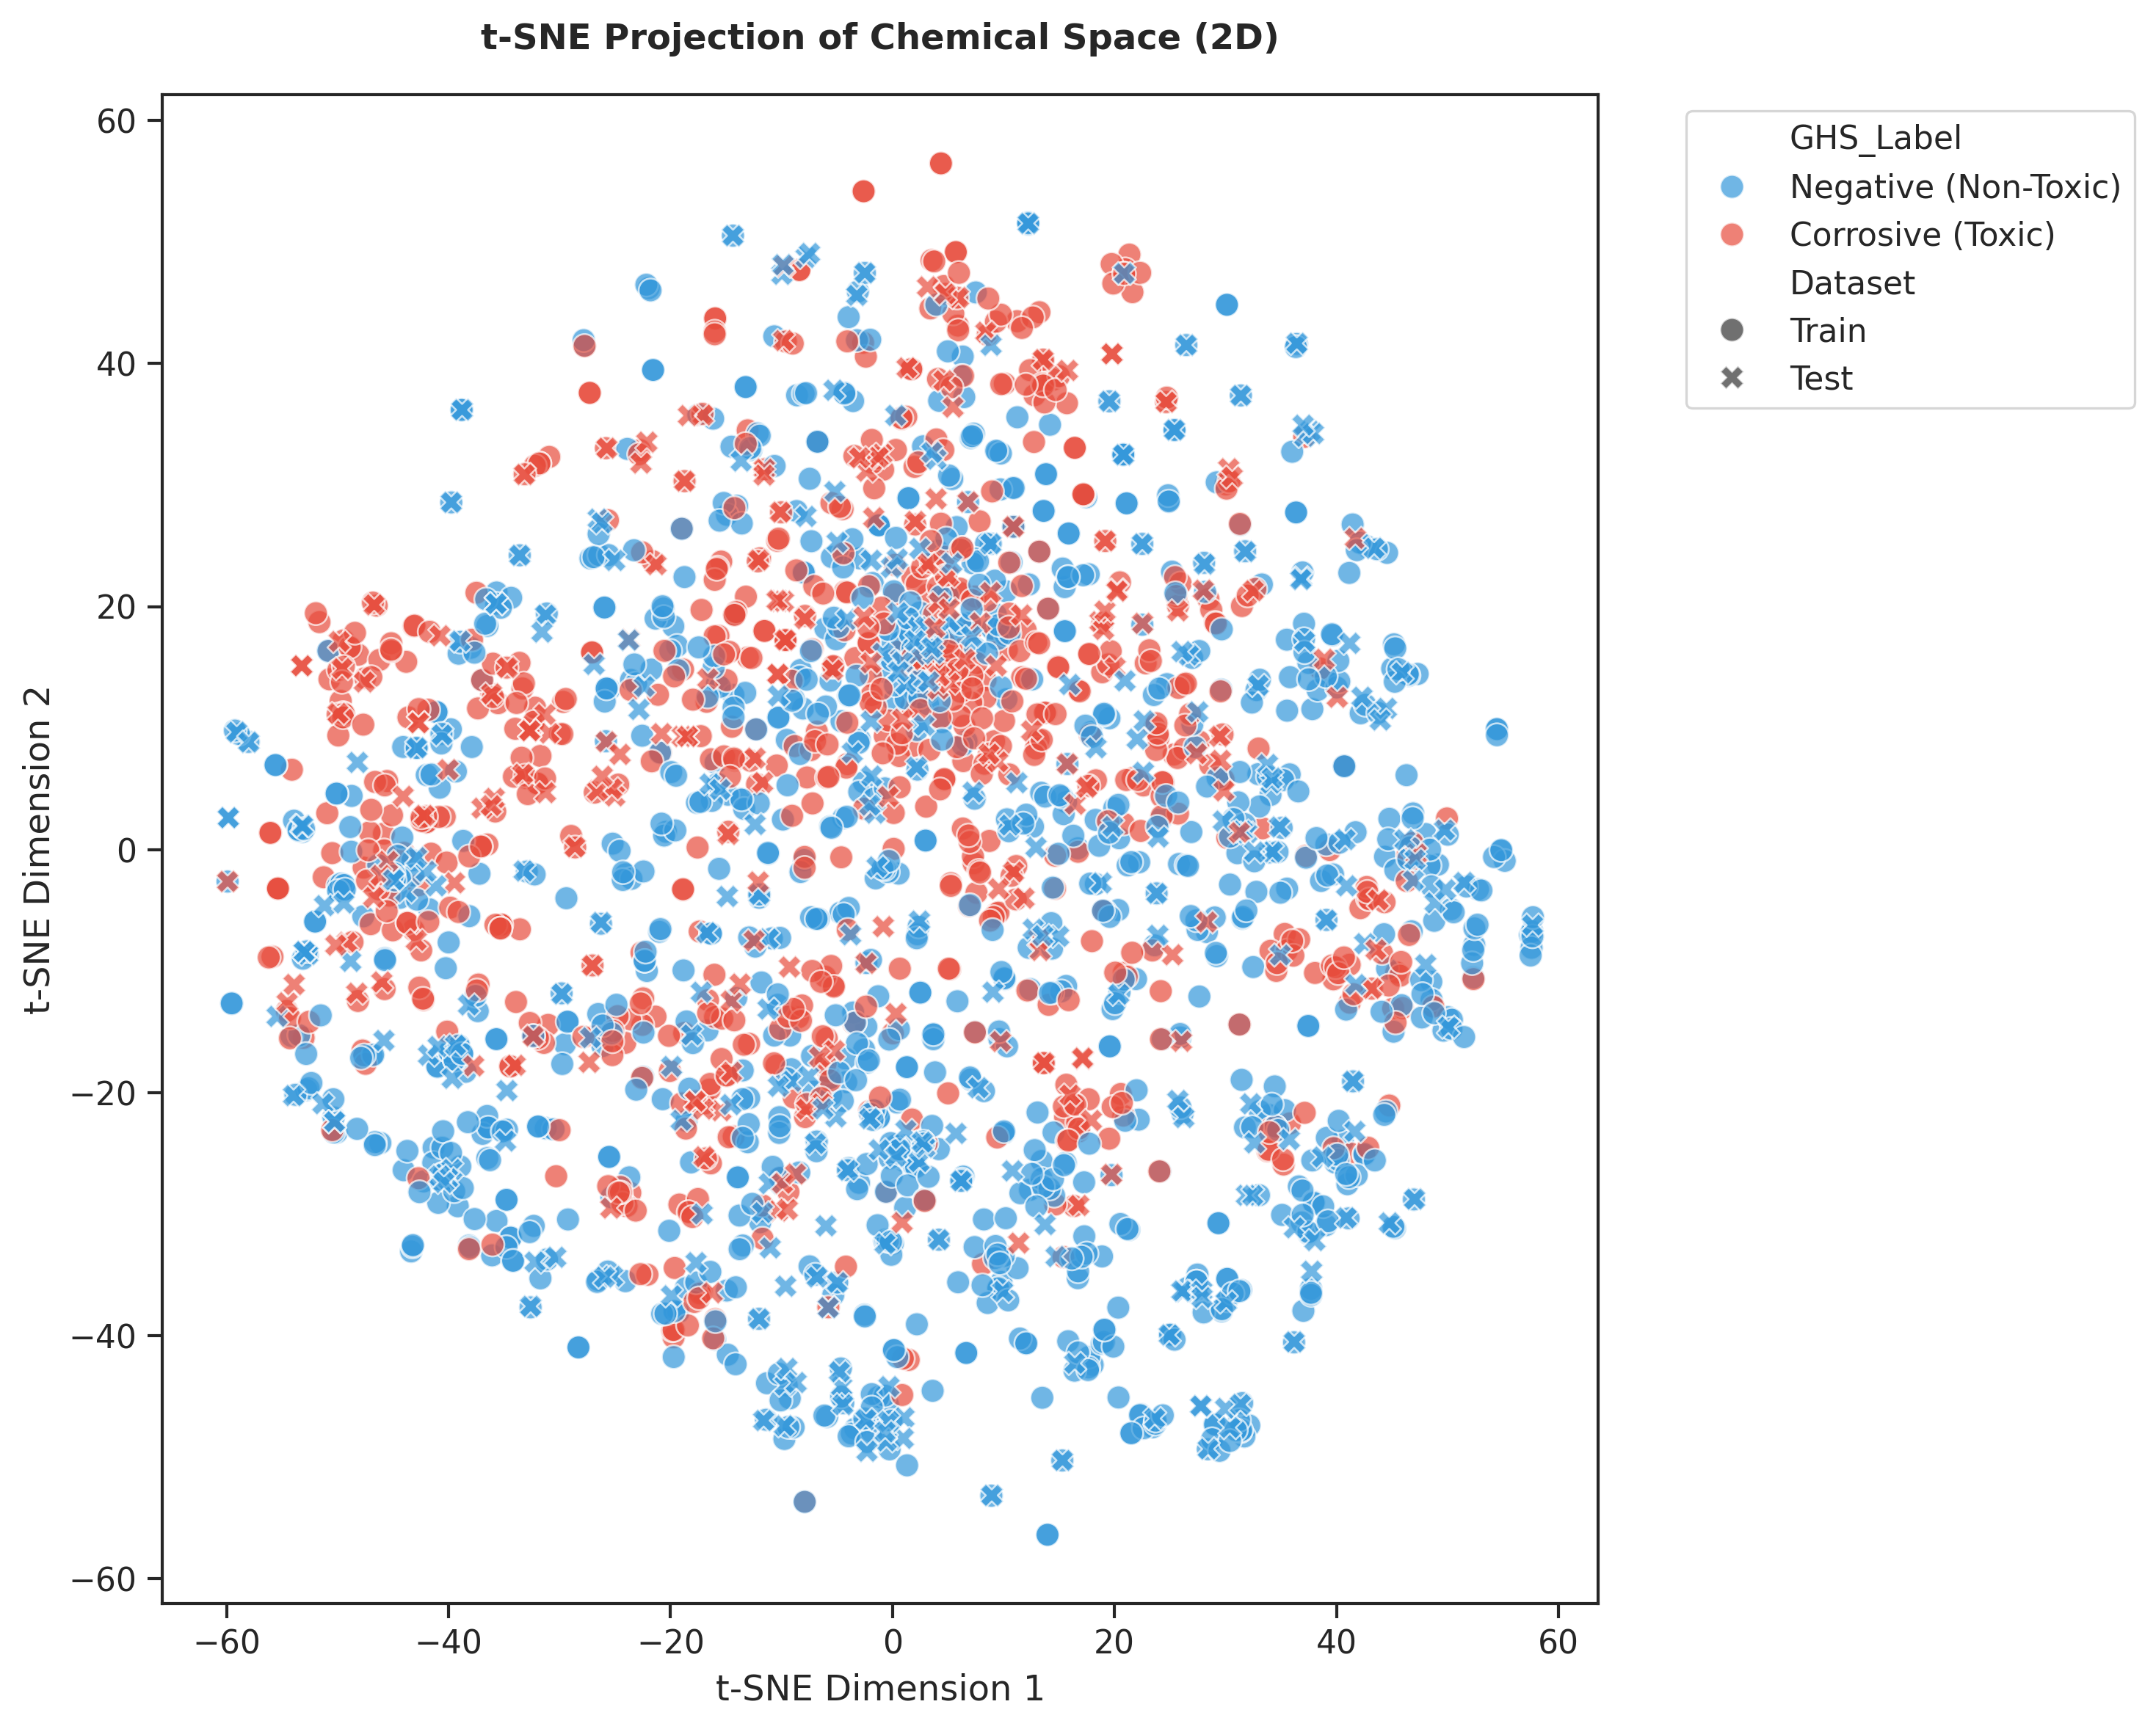

🔄 3D t-SNE 그래프를 생성합니다...
✅ 3D t-SNE (인터랙티브) 저장 완료: /content/drive/MyDrive/Attentive_FP/Results/Corr/ChemicalSpace/tSNE_3D_Interactive.html


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.manifold import TSNE
import os

# --- 1. Styles and Paths ---
sns.set_theme(style="ticks", context="paper", font_scale=1.2)
plt.rcParams["figure.dpi"] = 300
RESULTS_CHEM_SPACE = '/content/drive/MyDrive/Attentive_FP/Results/Corr/ChemicalSpace/'
os.makedirs(RESULTS_CHEM_SPACE, exist_ok=True)

# --- 2. Data Preparation ---
print("🔬 데이터 결합 및 Morgan Fingerprint 추출 중...")
train_df['Dataset'] = 'Train'
test_df['Dataset'] = 'Test'
combined_df = pd.concat([train_df, test_df], ignore_index=True)
combined_df['GHS_Label'] = combined_df['label'].map({1: 'Corrosive (Toxic)', 0: 'Negative (Non-Toxic)'})

def get_morgan_fp(smiles, radius=2, nBits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)
        return np.array(fp)
    return np.zeros((nBits,))

# Extract fingerprints
fps = np.array([get_morgan_fp(smi) for smi in combined_df['smiles']])
print(f"✅ 총 {len(fps)}개의 분자에서 Fingerprint 추출 완료!")

# --- 3. t-SNE Calculation ---
print("🔄 t-SNE 2D 및 3D 좌표 계산 중... (수 분이 소요될 수 있습니다)")
# 2D t-SNE
tsne_2d = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
fps_tsne_2d = tsne_2d.fit_transform(fps)
combined_df['t-SNE_1'] = fps_tsne_2d[:, 0]
combined_df['t-SNE_2'] = fps_tsne_2d[:, 1]

# 3D t-SNE
tsne_3d = TSNE(n_components=3, random_state=42, init='pca', learning_rate='auto')
fps_tsne_3d = tsne_3d.fit_transform(fps)
combined_df['t-SNE_3d_1'] = fps_tsne_3d[:, 0]
combined_df['t-SNE_3d_2'] = fps_tsne_3d[:, 1]
combined_df['t-SNE_3d_3'] = fps_tsne_3d[:, 2]
print("✅ t-SNE 계산 완료!")

# --- 4. 2D t-SNE 시각화 (Seaborn) ---
plt.figure(figsize=(10, 8))
palette = {'Corrosive (Toxic)': '#e74c3c', 'Negative (Non-Toxic)': '#3498db'}

sns.scatterplot(
    data=combined_df, x='t-SNE_1', y='t-SNE_2',
    hue='GHS_Label', style='Dataset',
    palette=palette, alpha=0.7, s=60, edgecolor='white'
)
plt.title('t-SNE Projection of Chemical Space (2D)', fontweight='bold', pad=15)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

save_path_tsne2d = os.path.join(RESULTS_CHEM_SPACE, 'tSNE_2D_Plot.png')
plt.savefig(save_path_tsne2d, dpi=300, bbox_inches='tight')
print(f"✅ 2D t-SNE 플롯 저장 완료: {save_path_tsne2d}")
plt.show()

# --- 5. 3D t-SNE 시각화 (Plotly) ---
print("🔄 3D t-SNE 그래프를 생성합니다...")
fig_3d_tsne = px.scatter_3d(
    combined_df, x='t-SNE_3d_1', y='t-SNE_3d_2', z='t-SNE_3d_3',
    color='GHS_Label', symbol='Dataset',
    color_discrete_map=palette, opacity=0.7,
    title='t-SNE Projection of Chemical Space (3D)'
)
fig_3d_tsne.update_traces(marker=dict(size=4, line=dict(width=1, color='White')))
fig_3d_tsne.update_layout(margin=dict(l=0, r=0, b=0, t=40))

# HTML로 저장
save_path_tsne3d = os.path.join(RESULTS_CHEM_SPACE, 'tSNE_3D_Interactive.html')
fig_3d_tsne.write_html(save_path_tsne3d)
print(f"✅ 3D t-SNE (인터랙티브) 저장 완료: {save_path_tsne3d}")
fig_3d_tsne.show()

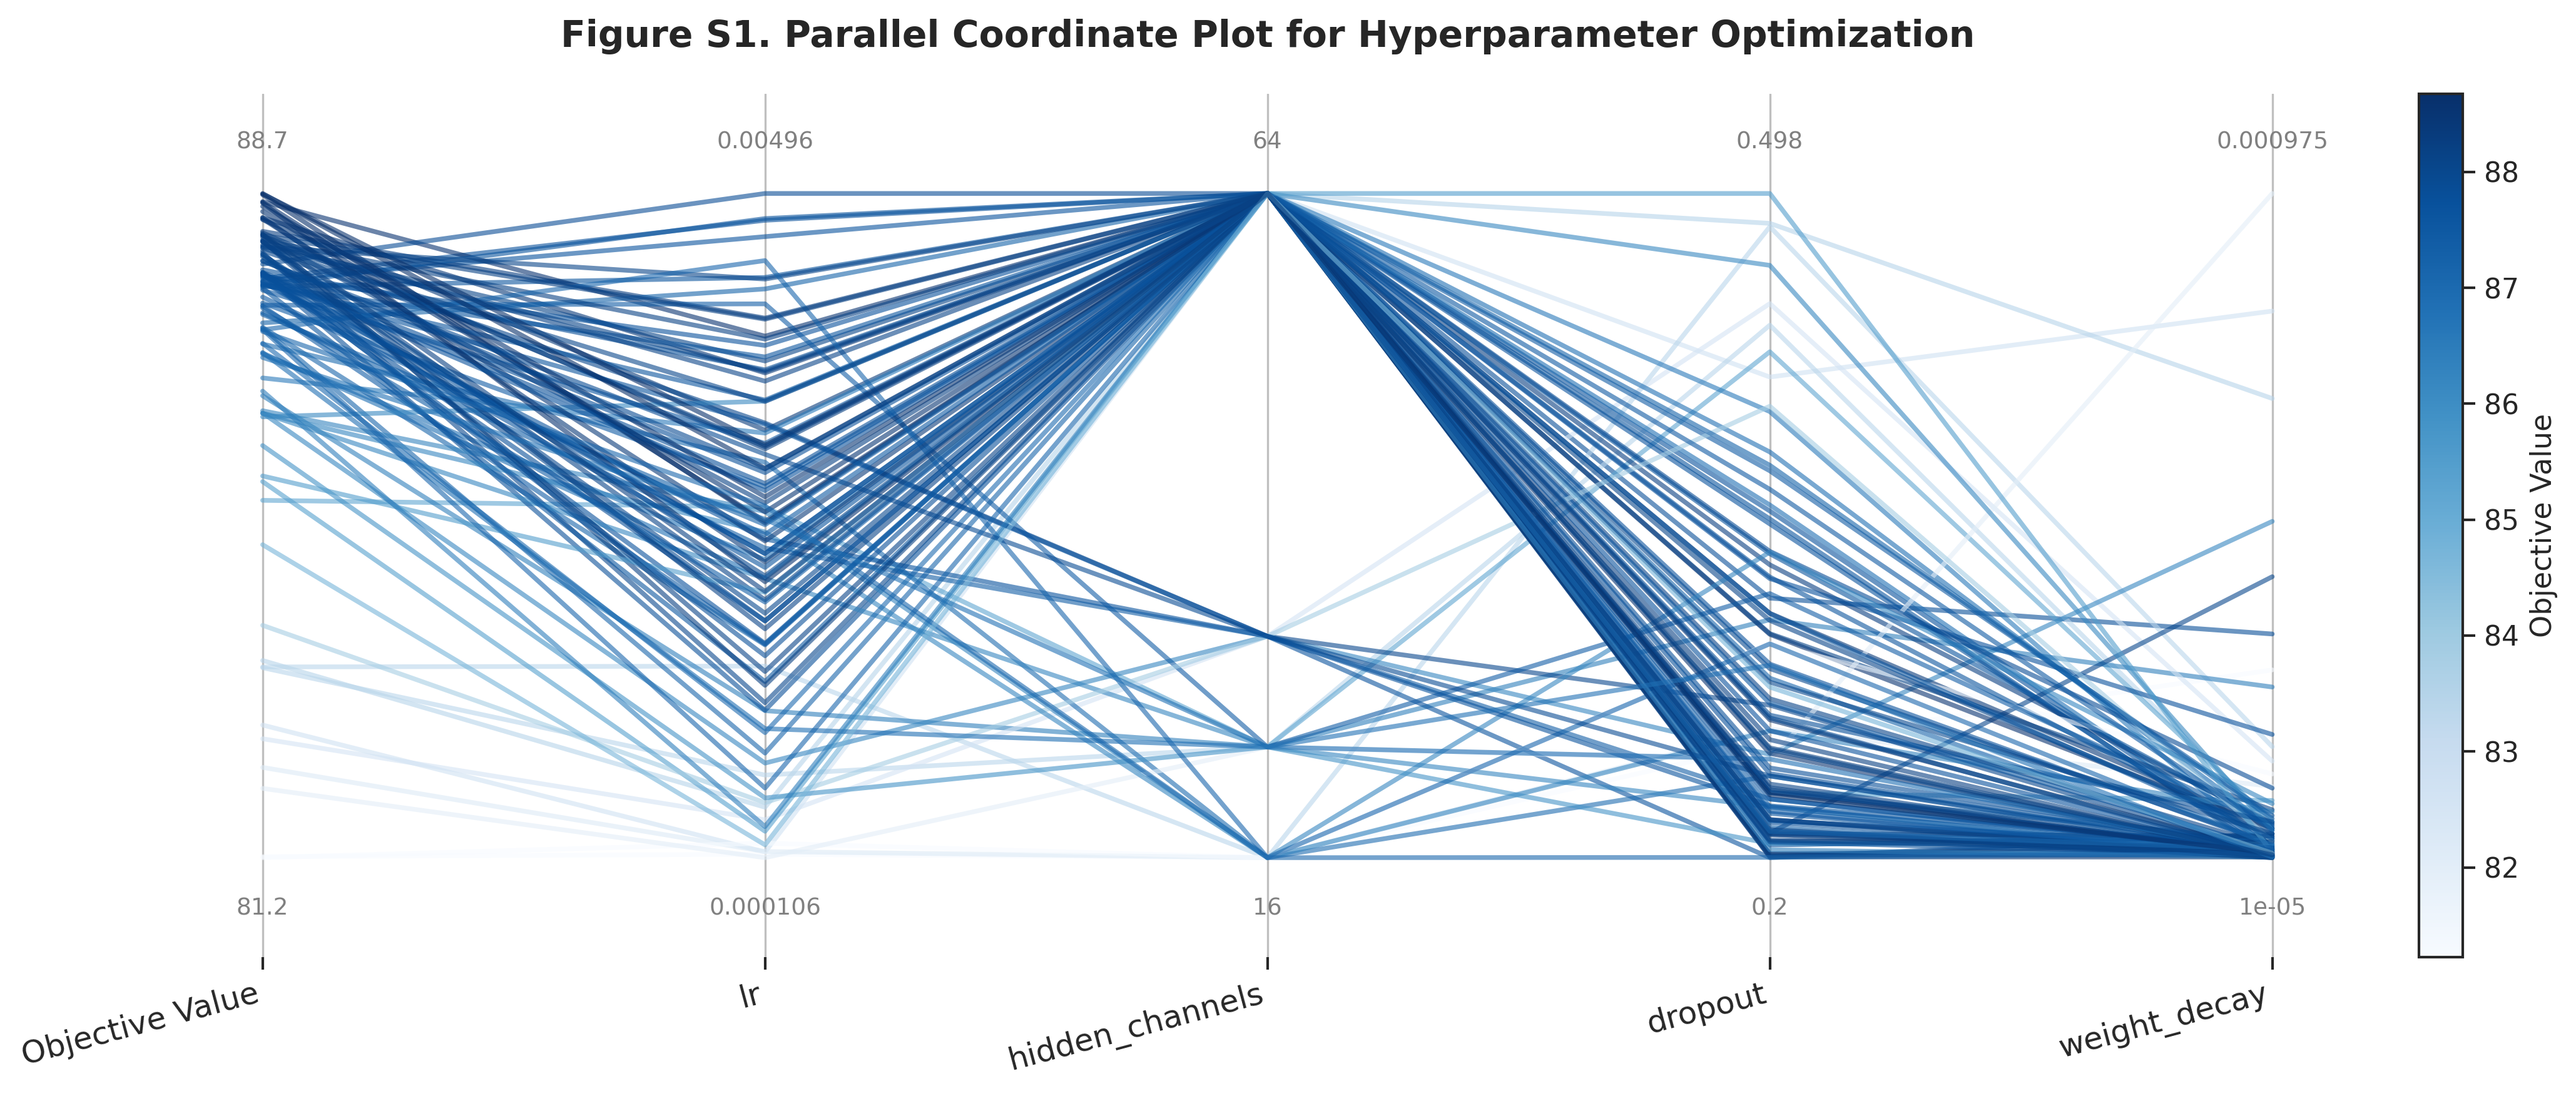

S1 저장 완료


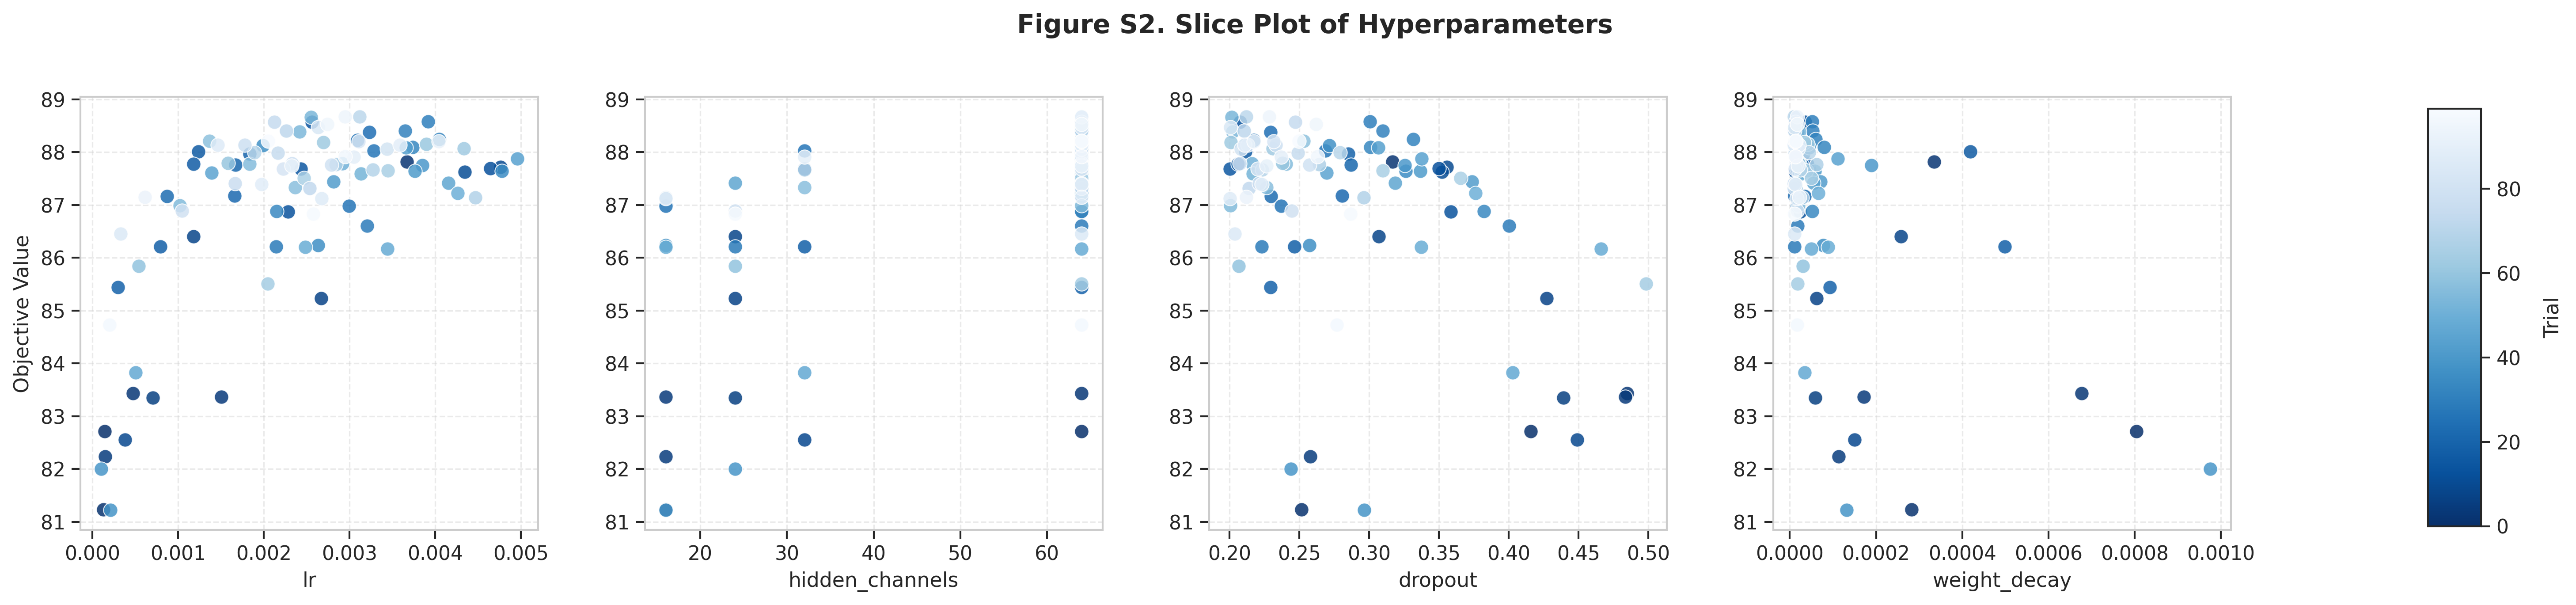

S2 저장 완료


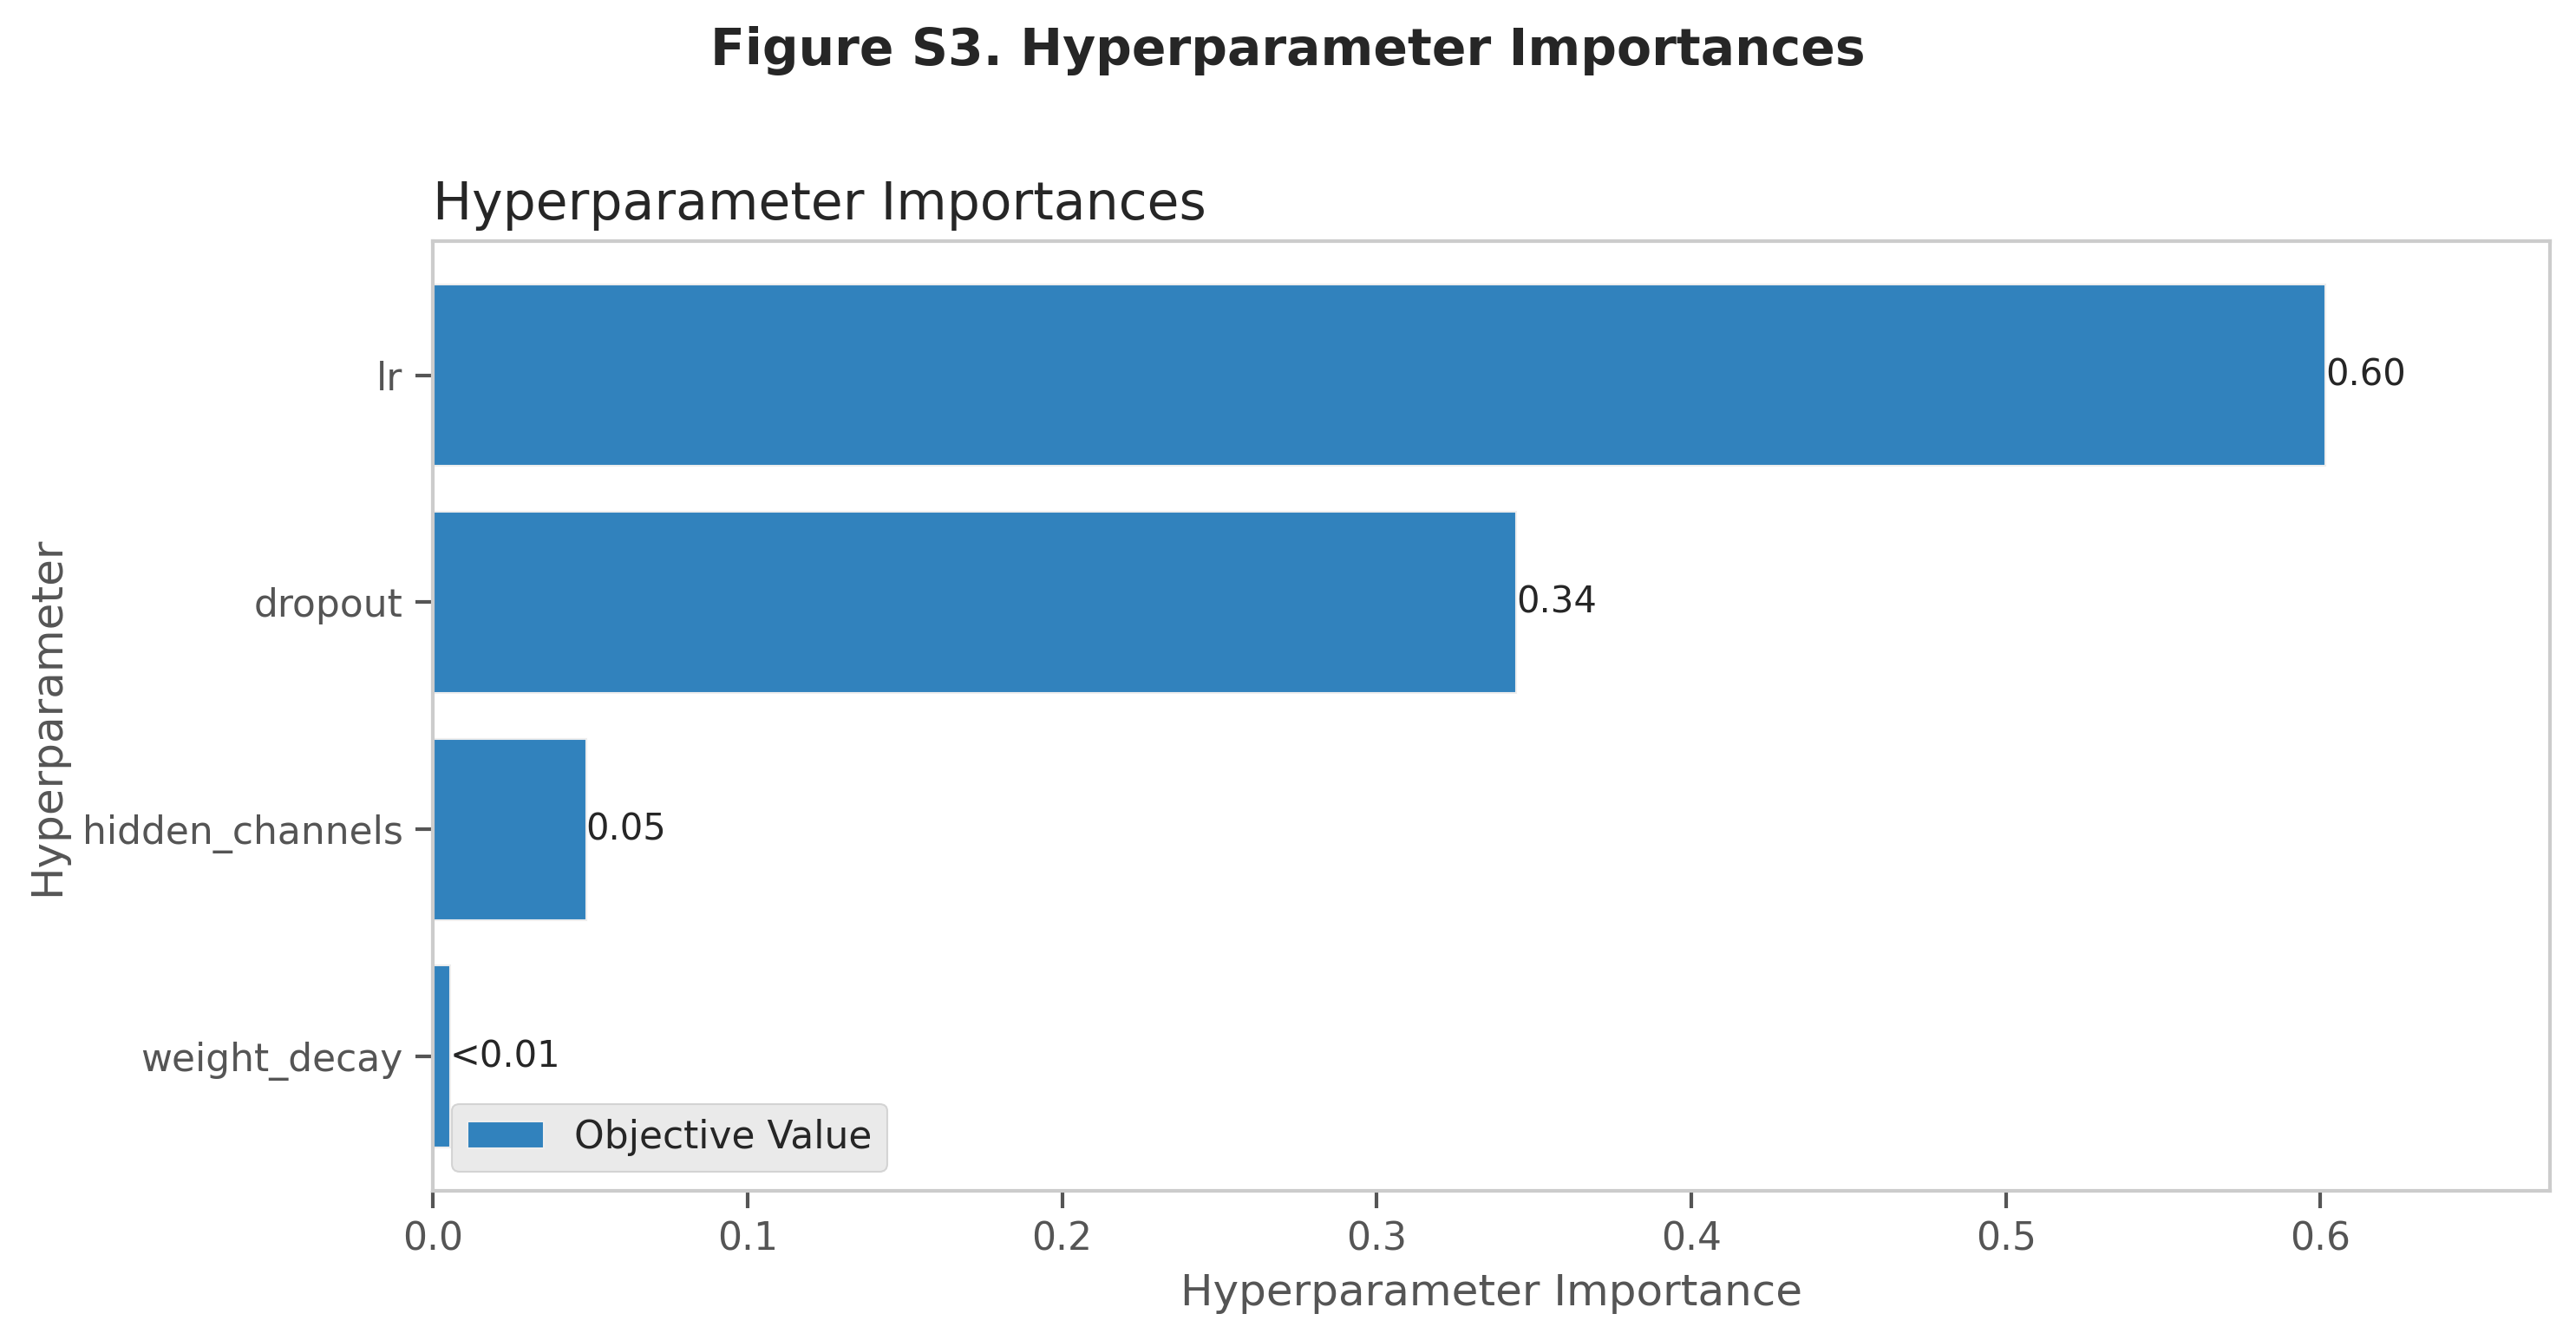

S3 저장 완료


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.cm as cm
import os, warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 12,
                     'axes.facecolor': 'white', 'figure.facecolor': 'white'})

save_dir = '/content/drive/MyDrive/Attentive_FP/Results/Corr/Optuna_Plots/'
os.makedirs(save_dir, exist_ok=True)

# ─── 공통 데이터 준비 ───────────────────────────────────────
trials_df = study.trials_dataframe()
trials_df = trials_df[trials_df['state'] == 'COMPLETE'].copy().reset_index(drop=True)
target_params = list(study.best_params.keys())
param_cols = [f'params_{p}' for p in target_params]
value_col  = 'value'

cmap_line  = cm.get_cmap('tab10')          # S1 선 색상 (tab10: 10가지 뚜렷한 색)
cmap_obj   = cm.get_cmap('Blues')          # objective 값 기반 색
norm_obj   = Normalize(vmin=trials_df[value_col].min(),
                       vmax=trials_df[value_col].max())

# ─── Figure S1: Parallel Coordinate Plot (직접 구현) ────────
all_cols    = [value_col] + param_cols
all_labels  = ['Objective Value'] + target_params

# 각 파라미터를 0~1로 정규화 (비교를 위해)
norm_df = pd.DataFrame()
for col in all_cols:
    lo, hi = trials_df[col].min(), trials_df[col].max()
    norm_df[col] = (trials_df[col] - lo) / (hi - lo) if hi > lo else 0.5

n_axes = len(all_cols)
fig_s1, ax_s1 = plt.subplots(figsize=(max(14, n_axes * 2.5), 6))
ax_s1.set_facecolor('white')
fig_s1.patch.set_facecolor('white')

x_pos = list(range(n_axes))

for idx, row in trials_df.iterrows():
    y_vals = [norm_df.loc[idx, c] for c in all_cols]
    color  = cmap_obj(norm_obj(row[value_col]))
    ax_s1.plot(x_pos, y_vals, color=color, alpha=0.6, linewidth=1.8, zorder=2)

# 세로 축선
for xi in x_pos:
    ax_s1.axvline(xi, color='gray', linewidth=0.8, alpha=0.5, zorder=1)

# 실제 값 눈금 표시 (각 축 상하에 min/max 표기)
for i, col in enumerate(all_cols):
    lo = trials_df[col].min()
    hi = trials_df[col].max()
    ax_s1.text(i, -0.06, f'{lo:.3g}', ha='center', va='top', fontsize=9, color='gray')
    ax_s1.text(i,  1.06, f'{hi:.3g}', ha='center', va='bottom', fontsize=9, color='gray')

ax_s1.set_xticks(x_pos)
ax_s1.set_xticklabels(all_labels, rotation=15, ha='right', fontsize=12)
ax_s1.set_yticks([])
ax_s1.set_ylim(-0.15, 1.15)
for spine in ax_s1.spines.values():
    spine.set_visible(False)

# 컬러바를 오른쪽 끝에 배치
sm = ScalarMappable(cmap=cmap_obj, norm=norm_obj)
sm.set_array([])
cbar = fig_s1.colorbar(sm, ax=ax_s1, pad=0.02, fraction=0.03)
cbar.set_label('Objective Value', fontsize=11)

ax_s1.set_title('Figure S1. Parallel Coordinate Plot for Hyperparameter Optimization',
                fontsize=14, fontweight='bold', pad=18)

fig_s1.tight_layout()
fig_s1.savefig(os.path.join(save_dir, 'Figure_S1_Final.png'), dpi=300, bbox_inches='tight')
plt.show()
print("S1 저장 완료")

# ─── Figure S2: Slice Plot (직접 구현, 컬러바 오른쪽 끝 고정) ─
n_params = len(target_params)
n_cols_sp = min(n_params, 4)
n_rows_sp = (n_params + n_cols_sp - 1) // n_cols_sp

# 컬러바 전용 열을 맨 오른쪽에 추가
fig_s2, axes_s2 = plt.subplots(
    n_rows_sp, n_cols_sp + 1,
    figsize=((n_cols_sp + 1) * 4, n_rows_sp * 4.5),
    gridspec_kw={'width_ratios': [4] * n_cols_sp + [0.35]}
)
fig_s2.patch.set_facecolor('white')

# axes_s2가 1행이면 shape 통일
if n_rows_sp == 1:
    axes_s2 = axes_s2.reshape(1, -1)

norm_trial = Normalize(vmin=0, vmax=len(trials_df) - 1)
cmap_trial = cm.get_cmap('Blues_r')

for pi, (param, pcol) in enumerate(zip(target_params, param_cols)):
    row_i = pi // n_cols_sp
    col_i = pi  % n_cols_sp
    ax = axes_s2[row_i, col_i]
    ax.set_facecolor('white')

    for idx, trial_row in trials_df.iterrows():
        color = cmap_trial(norm_trial(idx))
        ax.scatter(trial_row[pcol], trial_row[value_col],
                   color=color, s=60, alpha=0.85, edgecolors='white', linewidths=0.5)

    ax.set_xlabel(param, fontsize=11)
    ax.set_ylabel('Objective Value' if col_i == 0 else '', fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.4)
    for sp in ax.spines.values():
        sp.set_color('#cccccc')

# 빈 서브플롯 숨기기
for pi in range(n_params, n_rows_sp * n_cols_sp):
    row_i = pi // n_cols_sp
    col_i = pi  % n_cols_sp
    axes_s2[row_i, col_i].set_visible(False)

# 컬러바를 맨 오른쪽 열에 통합하여 표시
sm2 = ScalarMappable(cmap=cmap_trial, norm=norm_trial)
sm2.set_array([])

# 오른쪽 열 axes들을 하나로 합쳐 컬러바 배치
for r in range(n_rows_sp):
    axes_s2[r, -1].set_visible(False)

cbar_ax2 = fig_s2.add_axes([0.92, 0.15, 0.02, 0.7])   # [left, bottom, width, height]
cbar2 = fig_s2.colorbar(sm2, cax=cbar_ax2)
cbar2.set_label('Trial', fontsize=11, labelpad=12)

fig_s2.suptitle('Figure S2. Slice Plot of Hyperparameters',
                fontsize=14, fontweight='bold', y=1.01)

fig_s2.tight_layout(rect=[0, 0, 0.91, 1], h_pad=3.5, w_pad=2.5)
fig_s2.savefig(os.path.join(save_dir, 'Figure_S2_Final.png'), dpi=300, bbox_inches='tight')
plt.show()
print("S2 저장 완료")

# ─── Figure S3: Parameter Importances ───────────────────────
# ─── Figure S3: Parameter Importances ───────────────────────
import optuna.visualization.matplotlib as vis

ax_s3 = vis.plot_param_importances(study)
fig_s3 = ax_s3.figure
fig_s3.set_size_inches(10, 5)
fig_s3.patch.set_facecolor('white')
ax_s3.set_facecolor('white')

# ✅ optuna 내부 제목을 먼저 지우고 새 제목 설정
ax_s3.set_title('')
fig_s3.suptitle('Figure S3. Hyperparameter Importances',
                fontsize=14, fontweight='bold', y=1.02)

for sp in ax_s3.spines.values():
    sp.set_color('#cccccc')
ax_s3.grid(True, axis='x', linestyle='--', alpha=0.4)

fig_s3.tight_layout()
fig_s3.savefig(os.path.join(save_dir, 'Figure_S3_Final.png'), dpi=300, bbox_inches='tight')
plt.show()
print("S3 저장 완료")



## 코드 오류확인

In [ ]:
# ─── 1단계: df 상태 확인 ─────────────────────────────────────────
print("=== df 기본 정보 ===")
print(f"shape: {df.shape}")
print(f"columns: {df.columns.tolist()}")
print(f"smiles 컬럼 존재 여부: {'smiles' in df.columns}")
print()

# 컬럼명이 다를 경우를 대비해 유사한 컬럼 탐색
smiles_like_cols = [c for c in df.columns if 'smile' in c.lower() or 'smi' in c.lower()]
print(f"SMILES 관련 컬럼 후보: {smiles_like_cols}")
print()

print("=== label 분포 ===")
print(df['label'].value_counts() if 'label' in df.columns else "label 컬럼 없음")
print()

print("=== 첫 5행 ===")
print(df.head())


=== df 기본 정보 ===
shape: (2356, 2)
columns: ['smiles', 'label']
smiles 컬럼 존재 여부: True

SMILES 관련 컬럼 후보: ['smiles']

=== label 분포 ===
label
0    1394
1     962
Name: count, dtype: int64

=== 첫 5행 ===
                                              smiles  label
0                                                C=O      1
1  C[C@]12C[C@H](O)[C@H]3[C@@H](CCC4=CC(=O)C=C[C@...      0
2      CC1=CN([C@H]2C[C@H](O)[C@@H](CO)O2)C(=O)NC1=O      0
3                       CCCCOCCOCCOCc1cc2OCOc2cc1CCC      0
4                                   c1ccc2[nH]cnc2c1      0


In [ ]:
# ─── 2단계: SMILES 파싱 테스트 ──────────────────────────────────
from rdkit import Chem

smiles_col = 'smiles'  # 위에서 확인한 실제 컬럼명으로 교체하세요

total = len(df)
failed = []
for i, smi in enumerate(df[smiles_col]):
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None:
        failed.append((i, smi))

print(f"전체: {total}개 | 파싱 성공: {total - len(failed)}개 | 실패: {len(failed)}개")

if failed:
    print("\n파싱 실패한 SMILES 샘플 (최대 10개):")
    for idx, smi in failed[:10]:
        print(f"  행 {idx}: '{smi}'")


[11:29:34] Explicit valence for atom # 3 B, 4, is greater than permitted
[11:29:34] WARNING: not removing hydrogen atom without neighbors
[11:29:34] WARNING: not removing hydrogen atom without neighbors


전체: 2356개 | 파싱 성공: 2353개 | 실패: 3개

파싱 실패한 SMILES 샘플 (최대 10개):
  행 55: 'CCNB(F)(F)F'
  행 2117: 'O=Cl(=O)(=O)F'
  행 2192: 'ClCrH'


[11:29:34] Explicit valence for atom # 1 Cl, 7, is greater than permitted
[11:29:34] WARNING: not removing hydrogen atom without neighbors
[11:29:34] WARNING: not removing hydrogen atom without neighbors
[11:29:34] SMILES Parse Error: syntax error while parsing: ClCrH
[11:29:34] SMILES Parse Error: check for mistakes around position 4:
[11:29:34] ClCrH
[11:29:34] ~~~^
[11:29:34] SMILES Parse Error: Failed parsing SMILES 'ClCrH' for input: 'ClCrH'


In [ ]:
# ─── 3단계: get_morgan_fragments 직접 테스트 ─────────────────────
# df에서 파싱 성공한 첫 번째 SMILES로 테스트
smiles_col = 'smiles'  # 실제 컬럼명으로 교체

for smi in df[smiles_col]:
    mol = Chem.MolFromSmiles(str(smi))
    if mol is not None:
        test_smi = str(smi)
        break

print(f"테스트 SMILES: {test_smi}")
result = get_morgan_fragments(test_smi, radius=2)
print(f"추출된 프래그먼트 수: {len(result)}")
if result:
    print("첫 번째 프래그먼트:", list(result)[0])
else:
    print("⚠️ 프래그먼트 추출 실패! GetMorganGenerator 설정 문제입니다.")


테스트 SMILES: C=O
추출된 프래그먼트 수: 0
⚠️ 프래그먼트 추출 실패! GetMorganGenerator 설정 문제입니다.


In [ ]:
# 확인 테스트
test_cases = ['C=O', 'CCO', 'c1ccccc1', 'CCN(CC)CC']
for smi in test_cases:
    r1 = get_morgan_fragments(smi, radius=1)
    r2 = get_morgan_fragments(smi, radius=2)
    print(f"{smi:15s} → radius1: {len(r1)}개, radius2: {len(r2)}개")


C=O             → radius1: 1개, radius2: 0개
CCO             → radius1: 3개, radius2: 0개
c1ccccc1        → radius1: 2개, radius2: 4개
CCN(CC)CC       → radius1: 4개, radius2: 4개


[11:31:29] DEPRECATION WARNING: please use MorganGenerator
[11:31:29] DEPRECATION WARNING: please use MorganGenerator
[11:31:29] DEPRECATION WARNING: please use MorganGenerator
[11:31:29] DEPRECATION WARNING: please use MorganGenerator
[11:31:29] DEPRECATION WARNING: please use MorganGenerator
[11:31:29] DEPRECATION WARNING: please use MorganGenerator
[11:31:29] DEPRECATION WARNING: please use MorganGenerator
[11:31:29] DEPRECATION WARNING: please use MorganGenerator
